In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.5 MB/s eta 0:00:00


In [ ]:
# ==============================================
# 📦 Importações Principais e Organização
# ==============================================

# Geoespacial e Geometria
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union

# Redes e Grafos
import networkx as nx

# Numérico e Progresso
import pandas as pd
import numpy as np
from tqdm import tqdm

# Visualização e Estilo
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import random
import osmnx as ox
from matplotlib import colors
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Patches e Caminhos (para arcos e setas)
from matplotlib.patches import PathPatch, Arc, FancyArrowPatch
from matplotlib.path import Path

# PyG Temporal Install

In [ ]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch==2.2.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.10.0+cpu
Uninstalling torch-2.10.0+cpu:
  Successfully uninstalled torch-2.10.0+cpu
Found existing installation: torchvision 0.25.0+cpu
Uninstalling torchvision-0.25.0+cpu:
  Successfully uninstalled torchvision-0.25.0+cpu
Found existing installation: torchaudio 2.10.0+cpu
Uninstalling torchaudio-2.10.0+cpu:
  Successfully uninstalled torchaudio-2.10.0+cpu
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.2/757.2 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 59.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 44.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 56.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 41.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 71.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 758.9

In [ ]:
!pip install torch-scatter torch-sparse torch-geometric torch-geometric-temporal \
-f https://data.pyg.org/whl/torch-2.2.0+cu121.html

Looking in links: https://data.pyg.org/whl/torch-2.2.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 31.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 46.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 4.5 MB/s eta 0:00:00


In [ ]:
!pip install -U "numpy<2"

In [ ]:
import torch
import numpy as np
import networkx as nx

from torch_geometric_temporal.dataset.montevideo_bus import MontevideoBusDatasetLoader
from torch_geometric_temporal.dataset.chickenpox import ChickenpoxDatasetLoader
from torch_geometric_temporal.dataset.wikimath import WikiMathsDatasetLoader
from torch_geometric_temporal.dataset.encovid import EnglandCovidDatasetLoader


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================================================
# BUILD GRAPH (SIMETRIZAÇÃO CORRETA)
# =========================================================

def build_graph(edge_index, edge_weight, N):

    if torch.is_tensor(edge_index):
        edge_index = edge_index.cpu().numpy()

    if edge_weight is None:
        edge_weight = np.ones(edge_index.shape[1])
    else:
        edge_weight = edge_weight.cpu().numpy()

    G = nx.Graph()
    G.add_nodes_from(range(N))

    edges = set()

    for u, v in zip(edge_index[0], edge_index[1]):
        if u == v:
            continue
        a, b = (u, v) if u < v else (v, u)
        edges.add((a, b))

    G.add_edges_from(edges)

    return G


# =========================================================
# STRUCTURAL
# =========================================================

def structural_metrics(G):

    N = G.number_of_nodes()
    E = G.number_of_edges()

    deg = np.array([d for _, d in G.degree()])

    k_mean = deg.mean()
    d_max = deg.max()

    ratio = np.log(N) / np.log(k_mean) if k_mean > 1 else np.nan

    if nx.is_connected(G):
        diameter = nx.diameter(G)
    else:
        diameter = nx.diameter(G.subgraph(max(nx.connected_components(G), key=len)))

    return N, E, k_mean, d_max, ratio, diameter


# =========================================================
# LAPLACIAN
# =========================================================

def build_L(G, N):

    L = nx.normalized_laplacian_matrix(G, nodelist=range(N)).toarray()
    L = torch.tensor(L, dtype=torch.float32, device=device)
    return (L + L.T) / 2


# =========================================================
# SIGNAL
# =========================================================

def reduce_signal(x):

    if not torch.is_tensor(x):
        x = torch.tensor(x, dtype=torch.float32)

    if x.ndim > 1:
        x = x.mean(dim=1)

    x = (x - x.mean()) / (x.std() + 1e-8)

    return x.to(device)


# =========================================================
# SPECTRAL
# =========================================================

def spectral(L, x):

    x = reduce_signal(x)

    eigvals, U = torch.linalg.eigh(L)

    x_hat = U.T @ x
    energy = x_hat**2
    energy /= energy.sum() + 1e-8

    n = len(energy)

    low = energy[:n//3].sum().item()
    mid = energy[n//3:2*n//3].sum().item()
    high = energy[2*n//3:].sum().item()

    dirichlet = torch.dot(x, L @ x).item()

    return low, mid, high, dirichlet


# =========================================================
# PIPELINE
# =========================================================

def run(dataset, name):

    print(f"\n{name}")

    k_all, d_all, r_all, diam_all = [], [], [], []
    low_all, mid_all, high_all, dir_all = [], [], [], []

    cached_G, cached_L = None, None
    dynamic = (name == "EnglandCovid")

    T = 0

    for snap in dataset:

        if snap.edge_index is None or snap.x is None:
            continue

        N = snap.x.shape[0]

        if cached_G is None or dynamic:
            G = build_graph(snap.edge_index, getattr(snap, "edge_weight", None), N)
            L = build_L(G, N)

            if not dynamic:
                cached_G, cached_L = G, L
        else:
            G, L = cached_G, cached_L

        _, _, k, d, r, diam = structural_metrics(G)

        low, mid, high, dirichlet = spectral(L, snap.x)

        k_all.append(k)
        d_all.append(d)
        r_all.append(r)
        diam_all.append(diam)

        low_all.append(low)
        mid_all.append(mid)
        high_all.append(high)
        dir_all.append(dirichlet)

        T += 1

    print(f"<k>: {np.mean(k_all):.4f}")
    print(f"d_max: {np.mean(d_all):.2f}")
    print(f"Diameter: {np.mean(diam_all):.2f}")
    print(f"ln(N)/ln(<k>): {np.mean(r_all):.4f}")
    print(f"Low:  {np.mean(low_all):.4f}")
    print(f"Mid:  {np.mean(mid_all):.4f}")
    print(f"High: {np.mean(high_all):.4f}")
    print(f"Dirichlet mean: {np.mean(dir_all):.4f}")
    print(f"Dirichlet std:  {np.std(dir_all):.4f}")


# =========================================================
# RUN
# =========================================================

datasets = {
    "Chickenpox": ChickenpoxDatasetLoader().get_dataset(),
    "WikiMath": WikiMathsDatasetLoader().get_dataset(),
    "EnglandCovid": EnglandCovidDatasetLoader().get_dataset(),
    "MontevideoBus": MontevideoBusDatasetLoader().get_dataset(),
}

for name, data in datasets.items():
    run(data, name)


Chickenpox
<k>: 4.1000
d_max: 7.00
Diameter: 6.00
ln(N)/ln(<k>): 2.1231
Low:  0.2799
Mid:  0.3659
High: 0.3542
Dirichlet mean: 19.7310
Dirichlet std:  2.4564

WikiMath


In [ ]:
import numpy as np
import networkx as nx

from torch_geometric_temporal.dataset.montevideo_bus import MontevideoBusDatasetLoader
from torch_geometric_temporal.dataset.chickenpox import ChickenpoxDatasetLoader
from torch_geometric_temporal.dataset.wikimath import WikiMathsDatasetLoader
from torch_geometric_temporal.dataset.encovid import EnglandCovidDatasetLoader


def build_graph(edge_index, edge_weight, num_nodes):
    edge_index = edge_index.cpu().numpy()
    G = nx.Graph()

    if edge_weight is not None:
        edge_weight = edge_weight.cpu().numpy()
        for i in range(edge_index.shape[1]):
            u = int(edge_index[0, i])
            v = int(edge_index[1, i])
            w = float(edge_weight[i])
            G.add_edge(u, v, weight=w)
    else:
        G.add_edges_from(edge_index.T.tolist())

    G.add_nodes_from(range(num_nodes))
    return G


def spectral_analysis(G, x):
    A = nx.to_numpy_array(G)
    N = A.shape[0]

    deg = A.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(deg + 1e-8))
    L = np.eye(N) - D_inv_sqrt @ A @ D_inv_sqrt

    eigvals, U = np.linalg.eigh(L)

    x = x.squeeze()
    if x.ndim == 2:
        x = x.mean(axis=1)

    x_hat = U.T @ x
    energy = x_hat**2
    energy = energy / (energy.sum() + 1e-8)

    dirichlet = x.T @ L @ x

    return eigvals, energy, dirichlet


def compute_all(dataset, name):

    nodes_sum = 0.0
    edges_sum = 0.0
    avg_deg_sum = 0.0
    dmax_sum = 0.0
    weighted_flags = []

    low_e, mid_e, high_e = [], [], []
    dirichlet_vals = []

    T = 0

    for snapshot in dataset:
        edge_index = snapshot.edge_index
        if edge_index is None:
            continue

        T += 1

        N = snapshot.x.shape[0]
        G = build_graph(edge_index, getattr(snapshot, "edge_weight", None), N)

        nodes_sum += G.number_of_nodes()
        edges_sum += G.number_of_edges()

        degrees = np.array([d for _, d in G.degree()])
        avg_deg_sum += degrees.mean()
        dmax_sum += degrees.max()

        weighted_flags.append(
            any("weight" in data for _, _, data in G.edges(data=True))
        )

        eigvals, energy, dirichlet = spectral_analysis(G, snapshot.x.cpu().numpy())

        n = len(eigvals)
        low_e.append(energy[: n // 3].sum())
        mid_e.append(energy[n // 3 : 2 * n // 3].sum())
        high_e.append(energy[2 * n // 3 :].sum())
        dirichlet_vals.append(dirichlet)

    nodes = nodes_sum / T
    edges = edges_sum / T
    avg_deg = avg_deg_sum / T
    dmax = dmax_sum / T

    ratio = np.log(nodes) / np.log(avg_deg) if avg_deg > 1 else np.nan
    is_weighted = any(weighted_flags)

    print(f"{name}")
    print(f"T (snapshots): {T}")
    print(f"N (nodes): {nodes:.2f}")
    print(f"E (edges): {edges:.2f}")
    print(f"<k> (avg degree): {avg_deg:.4f}")
    print(f"d_max: {dmax:.2f}")
    print(f"weighted: {is_weighted}")
    print(f"ln(N)/ln(<k>): {ratio:.4f}")
    print(f"Low freq energy:  {np.mean(low_e):.4f}")
    print(f"Mid freq energy:  {np.mean(mid_e):.4f}")
    print(f"High freq energy: {np.mean(high_e):.4f}")
    print(f"Dirichlet energy (mean): {np.mean(dirichlet_vals):.4f}")
    print(f"Dirichlet energy (std):  {np.std(dirichlet_vals):.4f}")
    print("-" * 60)


datasets = {
    "Chickenpox": ChickenpoxDatasetLoader().get_dataset(),
    "WikiMath": WikiMathsDatasetLoader().get_dataset(),
    "EnglandCovid": EnglandCovidDatasetLoader().get_dataset(),
    "MontevideoBus": MontevideoBusDatasetLoader().get_dataset(),
}

for name, data in datasets.items():
    compute_all(data, name)

Chickenpox
T (snapshots): 517
N (nodes): 20.00
E (edges): 61.00
<k> (avg degree): 6.1000
d_max: 9.00
weighted: False
ln(N)/ln(<k>): 1.6567
Low freq energy:  0.4678
Mid freq energy:  0.2697
High freq energy: 0.2625
Dirichlet energy (mean): 0.8530
Dirichlet energy (std):  0.8280
------------------------------------------------------------


KeyboardInterrupt: 

# Visão geral



## Datasets



---

| Dataset                | Tipo de Grafo                 | Direcionado | Weighted | Granularidade Temporal | Snapshots (T) | Treino | Validação | Teste | $|\mathcal{V}|$ | $|\mathcal{E}|$ | Features por Nó | Média x | Desvio x | Média y | Desvio y | Descrição Breve                                                                                                                                                                                                                  |
| ---------------------- | ----------------------------- | ----------- | -------- | ---------------------- | ------------- | ------ | --------- | ----- | ------------- | ----------------- | --------------- | ------- | -------- | ------- | -------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **ChickenpoxHungary** | Estático | ❌ Não       | ✅ Sim    | Semanal                | 513           | 359    | 77        | 77    | 20            | 61               | 8               | 0.4662  | 0.1645   | 0.5494  | 0.0973   | Casos semanais de catapora em 20 condados da Hungria (2004–2014). Cada nó representa um condado e as arestas indicam conectividade geográfica entre regiões vizinhas.                                                            |
| **PedalMe**            | Estático                      | ✅ Sim       | ✅ Sim    | Horária (~30 min)      | 27            | 18     | 4         | 5     | 15            | 225               | 8               | 0.2637  | 0.1734   | 0.4809  | 0.1481   | Rede de entregas urbanas da empresa PedalMe em Londres (2020–2021). Os nós representam zonas da cidade e as arestas indicam rotas de entrega ponderadas pela frequência de corridas.                                             |
| **WikiMaths**          | Estático                      | ❌ Não       | ✅ Sim    | Semanal                | 723           | 506    | 108       | 109   | 1,068         | 27,079            | 8               | 0.1834  | 0.0550   | 0.0992  | 0.0171   | Rede de artigos de matemática da Wikipédia (2019–2021). Cada nó representa uma página e as arestas indicam hiperligações entre artigos correlacionados.                                                                          |
| **EnglandCovid**       | Dinâmico                      | ✅ Sim       | ✅ Sim    | Diária                 | 53            | 37     | 8         | 8     | 129           | 2,158             | 8               | 0.3196  | 0.1548   | 0.1099  | 0.0567   | Série temporal de mobilidade e casos de COVID-19 entre regiões NUTS-3 da Inglaterra (mar–mai 2020). O grafo é direcionado e ponderado, variando conforme fluxos de mobilidade diária.                                            |
| **MontevideoBus**      | Estático                      | ✅ Sim       | ✅ Sim    | Horária                | 736           | 515    | 110       | 111   | 675           | 690               | 8               | 0.1273  | 0.0676   | 0.0682  | 0.0521   | Rede de transporte público de Montevidéu (outubro/2020). Os nós são paradas de ônibus e as arestas conectam paradas atendidas por uma mesma linha. Pesos representam distância e o sinal temporal indica fluxo horário (inflow). |
| **PeMSBay**            | Estático                      | ✅ Sim       | ✅ Sim    | 5 minutos              | 52,097        | 36,467 | 7,815     | 7,815 | 325           | 2,694             | 2               | 0.4121  | 0.1782   | 0.3917  | 0.1624   | Dados de sensores de tráfego da Califórnia (PeMS, Bay Area). Cada nó representa uma estação de monitoramento, e as arestas conectam estações com proximidade geográfica e correlação de fluxo veicular.                          |
| **TwitterTennis-RG17** | Dinâmico                      | ✅ Sim       | ✅ Sim    | 5 minutos              | 120           | 84     | 18        | 18    | 1,000         | 89                | 16              | 0.2281  | 0.0759   | 0.3194  | 0.0856   | Rede temporal de menções e retuítes no Twitter durante o **Roland-Garros 2017**. Mais densa e estável, com comunidades coesas (mídia europeia, WTA/ATP). Útil para testar **consistência temporal** em GNNs.                     |
| **TwitterTennis-UO17** | Dinâmico                      | ✅ Sim       | ✅ Sim    | 5 minutos              | 112           | 78     | 17        | 17    | 1,000         | 88                | 16              | 0.2078  | 0.0723   | 0.3145  | 0.0811   | Rede temporal de menções e retuítes no Twitter durante o **US Open 2017**. Mais variável e reativa, com flutuações abruptas nas interações. Útil para testar **mudanças de topologia e reatividade** em GNNs.                    |

## Arquiteturas

| Nome         | Ano  | Classificação | Módulo Temporal                   | Módulo Espacial                 | Artigo                                                                                                |
| ------------ | ---- | ------------- | --------------------------------- | ------------------------------- | ----------------------------------------------------------------------------------------------------- |
| CaST         | 2023 | Atencional    | Self-Attention + FFT              | Message Passing (GNN)           | Deciphering Spatio-Temporal Graph Forecasting: A Causal Lens and Treatment                            |
| GMAN         | 2020 | Atencional    | Multi-head Temporal Attention     | Spatial Attention / GNN         | GMAN: A Graph Multi-Attention Network for Traffic Prediction                                          |
| STAEformer   | 2023 | Atencional    | Self-Attention                    | Embeddings + Top-K Attention    | STAEformer: Spatio-Temporal Adaptive Embedding Makes Vanilla Transformer SOTA for Traffic Forecasting |
| STGNN        | 2020 | Atencional    | Atenção Temporal                  | GNN Espacial                    | Traffic Flow Prediction via Spatial Temporal Graph Neural Network                                     |
| STGraphormer | 2021 | Atencional    | Transformer Temporal              | Graphormer Attention            | Do Transformers Really Perform Bad for Graph Representation?                                          |
| TGAT         | 2022 | Atencional    | Time Encoding + Attention         | Attention baseada em vizinhança | Temporal Graph Attention Network for Building Thermal Load Prediction                                 |
| AAGCN        | 2024 | Convolucional | Temporal Conv (TCN)               | GCN Adaptativo                  | AAGCN: A Graph Convolutional Neural Network with Adaptive Feature and Topology Learning               |
| GraphWaveNet | 2019 | Convolucional | Dilated Causal Conv               | Graph Convolution               | Graph WaveNet for Deep Spatial-Temporal Graph Modeling                                                |
| LSGCN        | 2020 | Convolucional | GLU + Temporal Conv               | Chebyshev GCN                   | LSGCN: Long Short-Term Traffic Prediction with Graph Convolutional Networks                           |
| MTGNN        | 2020 | Convolucional | Temporal Conv (dilated/inception) | Graph Learning + Propagation    | Connecting the Dots: Multivariate Time Series Forecasting with Graph Neural Networks                  |
| SLCNN        | 2020 | Convolucional | Temporal Conv                     | Global + Local Chebyshev GCN    | Spatiotemporal Graph Structure Learning for Traffic Forecasting                                       |
| STGCN        | 2018 | Convolucional | Temporal Conv                     | Chebyshev GCN                   | Spatio-Temporal Graph Convolutional Networks: A Deep Learning Framework for Traffic Forecasting       |
| DCRNN        | 2018 | Recorrente    | GRU                               | Diffusion Graph Convolution     | Diffusion Convolutional Recurrent Neural Network: Data-Driven Traffic Forecasting                     |
| DyGrAE       | 2018 | Recorrente    | LSTM                              | GCN                             | Predictive Temporal Embedding of Dynamic Graphs                                                       |
| EvolveGCN-H  | 2020 | Recorrente    | GRU (evolução de pesos)           | GCN                             | EvolveGCN: Evolving Graph Convolutional Networks for Dynamic Graphs                                   |
| EvolveGCN-O  | 2020 | Recorrente    | GRU (output evolving)             | GCN                             | EvolveGCN: Evolving Graph Convolutional Networks for Dynamic Graphs                                   |
| GCLSTM       | 2018 | Recorrente    | LSTM                              | Chebyshev GCN                   | GC-LSTM: Graph Convolution Embedded LSTM for Dynamic Link Prediction                                  |
| GConvGRU     | 2019 | Recorrente    | GRU                               | Chebyshev GCN                   | Structured Sequence Modeling with Graph Convolutional Recurrent Networks                              |
| GConvLSTM    | 2019 | Recorrente    | LSTM                              | Chebyshev GCN                   | Structured Sequence Modeling with Graph Convolutional Recurrent Networks                              |
| MPNN-LSTM    | 2020 | Recorrente    | LSTM                              | Message Passing                 | Transfer Graph Neural Networks for Pandemic Forecasting                                               |
| TGCN         | 2019 | Recorrente    | GRU                               | GCN                             | T-GCN: A Temporal Graph Convolutional Network for Traffic Prediction                                  |

---



# Pipeline

Input Sequence (B, T, N, F)  
$$\downarrow$$  
Representa a entrada completa do modelo.  
- B = batch size, ou seja, quantas amostras entram juntas no treinamento  
- T = número de passos temporais observados (lags/janela temporal)  
- N = número de nós do grafo  
- F = número de features por nó em cada instante  

Em termos simples:  
é uma sequência temporal multivariada sobre um grafo.  
Exemplo: para cada semana (T), cada região (N) possui atributos/canais (F).  

$$\downarrow$$  
Input Projection (Linear: F → hidden)  
$$\downarrow$$  
É a camada inicial que projeta as features originais para um espaço latente comum de dimensão hidden.  

Por que isso é importante:  
- padroniza a entrada para diferentes arquiteturas  
- permite comparar modelos de forma justa  
- aumenta a capacidade de representação antes do bloco espaço-temporal  
- transforma sinais crus em embeddings mais ricos  

Em termos simples:  
é como traduzir os dados brutos para uma “linguagem interna” que o modelo entende melhor.  

Se F for pequeno, essa etapa também ajuda a enriquecer a representação.  
Se F for grande, ela ajuda a comprimir e organizar a informação.  

$$\downarrow$$  
Spatio-Temporal GNN Block  
    (varia por arquitetura: GCN / Attention / Diffusion / etc.)  
$$\downarrow$$  
Esse é o núcleo do modelo. Aqui o modelo aprende simultaneamente:  
- dependências espaciais: como os nós influenciam uns aos outros  
- dependências temporais: como o passado influencia o futuro  

Esse bloco muda conforme a arquitetura:  
- GCN / ChebConv: agregam informação dos vizinhos no grafo  
- Diffusion: propagam informação como fluxo na rede  
- Attention / Transformer: aprendem quais nós e instantes são mais relevantes  
- Temporal Conv: capturam padrões locais no tempo com convoluções  
- Recurrent cells: atualizam estados ocultos ao longo dos passos temporais  

Em termos simples:  
é a parte que faz o modelo “olhar para os vizinhos e para o histórico” ao mesmo tempo.  

Por que isso é forte:  
- combina estrutura relacional + dinâmica temporal  
- usa o grafo para restringir ou guiar a troca de informação  
- consegue explorar padrões que modelos puramente temporais perderiam  

$$\downarrow$$  
Temporal Processing (loop ou bloco)  
$$\downarrow$$  
Depois do bloco espaço-temporal, o processamento temporal acontece explicitamente ao longo dos instantes.  

Isso pode ocorrer de duas formas principais:  
- loop temporal:  
  o modelo processa passo a passo, atualizando um estado oculto  
  comum em GRU, LSTM, TGCN, DCRNN etc.  
- bloco temporal:  
  o modelo processa toda a sequência de uma vez  
  comum em CNNs temporais e Transformers  

Em termos simples:  
é o mecanismo que decide como o modelo “acompanha a história” dos dados.  

Por que isso importa:  
- alguns padrões dependem muito da ordem dos eventos  
- alguns dependem de relações de curto prazo  
- outros exigem memória longa  

Essa etapa é a responsável por modelar a evolução temporal propriamente dita.  

$$\downarrow$$  
Temporal Residual (h += h_prev)  
$$\downarrow$$  
Aqui entra uma conexão residual entre estados temporais consecutivos.  

Forma típica:  
- h = h + h_prev  

O que isso faz:  
- mantém parte da informação anterior viva  
- facilita o fluxo de gradiente no treinamento  
- reduz perda de informação entre passos  
- ajuda a estabilizar arquiteturas profundas ou recorrentes  

Em termos simples:  
ao invés de substituir totalmente o estado anterior, o modelo “soma o que já sabia” com a nova informação.  

Por que isso é forte:  
- combate vanishing gradient  
- reduz degradação do sinal temporal  
- ajuda a preservar memória útil  
- pode aliviar efeitos de over-smoothing temporal ou espacial indireto  

$$\downarrow$$  
LayerNorm (temporal)  
$$\downarrow$$  
LayerNorm normaliza a representação em cada passo, mantendo a escala dos valores mais estável.  

O que faz:  
- recentra e reescala a ativação  
- evita explosões ou colapsos numéricos  
- melhora estabilidade do treinamento  

Em termos simples:  
é como “organizar a faixa de valores” para que o modelo não fique desbalanceado.  

Por que colocar depois do residual temporal:  
- a soma residual pode alterar a escala da representação  
- a normalização estabiliza o que será passado adiante  

Isso costuma deixar o treinamento mais robusto, principalmente em séries temporais pequenas ou ruidosas.  

$$\downarrow$$  
Residual com último snapshot (skip connection)  
$$\downarrow$$  
Aqui o estado final recebe uma conexão direta com a última observação da entrada.  

Forma típica:  
- h = h + x_last  

O que isso significa:  
- o modelo reaproveita explicitamente a informação mais recente  
- garante que o último estado observado tenha influência direta na previsão  

Em termos simples:  
além de aprender padrões complexos, o modelo não “esquece” o presente imediato.  

Por que isso é muito útil:  
- em previsão temporal, o instante mais recente costuma carregar muita informação  
- melhora estabilidade  
- reduz o risco do modelo distorcer excessivamente a entrada após muitas transformações  

Essa conexão é particularmente forte em forecasting, porque frequentemente o futuro próximo depende muito do passado imediato.  

$$\downarrow$$  
LayerNorm  
$$\downarrow$$  
Após a soma com o último snapshot, aplica-se outra normalização.  

Função:  
- estabilizar novamente a representação  
- compensar a mudança de escala causada pelo skip connection  
- preparar melhor os dados para a ativação seguinte  

Em termos simples:  
é uma segunda “organização” dos valores antes da parte final da previsão.  

Ter duas normalizações em pontos estratégicos costuma melhorar bastante a robustez do pipeline.  

$$\downarrow$$  
ReLU  
$$\downarrow$$  
ReLU é a função de ativação não linear.  

Ela faz:  
- valores positivos permanecem  
- valores negativos viram zero  

Por que isso é importante:  
- introduz não linearidade  
- permite ao modelo aprender padrões complexos  
- evita que a rede vire apenas uma transformação linear grande  

Em termos simples:  
ela ajuda o modelo a capturar relações mais ricas e menos triviais.  

A ReLU também é simples, eficiente e muito estável em treinamento.  

$$\downarrow$$  
Dropout  
$$\downarrow$$  
Dropout é regularização.  

O que faz:  
- desliga aleatoriamente parte dos neurônios durante o treino  
- evita que o modelo dependa demais de poucos caminhos internos  
- reduz overfitting  

Em termos simples:  
é como obrigar o modelo a não “decorar” demais o treino.  

Por que isso é importante no seu cenário:  
- datasets espaço-temporais pequenos podem superajustar facilmente  
- a regularização ajuda a generalização  
- especialmente útil depois de camadas ricas em parâmetros  

$$\downarrow$$  
Linear Forecast Head (hidden → horizon)  
$$\downarrow$$  
Essa é a camada final de previsão.  

Ela pega a representação latente final de cada nó e transforma em previsão para o horizonte desejado.  

Se horizon = H:  
- a camada produz H valores para cada nó  

Em termos simples:  
é a parte que converte o que o modelo aprendeu em números previstos.  

Exemplo:  
- horizonte 1 → previsão do próximo passo  
- horizonte 5 → previsão dos próximos 5 passos  

Essa camada é linear porque a parte complexa da modelagem já foi feita antes.  

$$\downarrow$$  
Output (B, horizon, N)  
$$\downarrow$$  
É a saída final do modelo.  

Dimensões:  
- B = número de amostras no batch  
- horizon = número de passos futuros previstos  
- N = número de nós  

Em termos simples:  
para cada amostra e para cada nó do grafo, o modelo retorna uma sequência de previsões futuras.  

Esse formato é ideal para tarefas de forecasting multistep em grafos.  

Resumo conceitual do pipeline:  
esse pipeline é forte porque combina:  
- projeção inicial para enriquecer a entrada  
- modelagem espaço-temporal explícita  
- processamento temporal consistente  
- conexões residuais para preservar informação  
- normalização para estabilidade  
- regularização para generalização  
- cabeça final simples e objetiva para forecasting  

Em termos leigos:  
ele pega dados brutos no tempo sobre vários nós conectados, aprende como os nós se influenciam, aprende como o passado evolui, preserva as informações mais importantes ao longo do caminho e, no final, transforma isso em previsões futuras de forma estável e robusta.

# Chickenpox Hungary Dataset

In [ ]:
# -*- coding: utf-8 -*-
"""
Classe HungaryNetwork:
- Carrega o mapa base da Hungria
- Calibra e plota automaticamente uma rede (Gephi)
- Ajusta nós aos centróides dos condados
- Aplica estilo TP1 (Gephi)
- Exibe distribuição de graus com seaborn
"""

class HungaryNetwork:
    def __init__(self, geojson_path, graph_path):
        """Inicializa com caminhos do mapa base e do arquivo GraphML."""
        self.geojson_path = geojson_path
        self.graph_path = graph_path
        self.gdf_clean = None
        self.hungary_shape = None
        self.G = None
        self.G_original = None
        self.r = None
        self.pos = None
        self.node_sizes = None
        self.node_colors = None
        self.border_colors = None
        self.edge_colors = None
        self.edge_widths = None
        self.node_alpha = None

    # ============================================================
    # 1️⃣ Mapa base
    # ============================================================
    def load_and_prepare_map(self):
        """Carrega o mapa da Hungria e combina pequenas cidades com condados."""
        print("📍 Carregando mapa base da Hungria...")
        gdf = gpd.read_file(self.geojson_path).to_crs(epsg=23700)
        nomes = [
            "Baranya", "Békéscsaba", "Békés", "Bács-Kiskun", "Budapest",
            "Borsod-Abaúj-Zemplén", "Csongrád", "Debrecen", "Dunaújváros",
            "Eger", "Érd", "Fejér", "Gyor-Moson-Sopron", "Gyôr",
            "Hajdú-Bihar", "Heves", "Hódmezôvásárhely", "Jász-Nagykun-Szolnok",
            "Komárom-Esztergom", "Kecskemét", "Kaposvár", "Miskolc",
            "Nagykanizsa", "Nógrád", "Nyíregyháza", "Pest", "Pécs",
            "Szeged", "Székesfehérvár", "Szombathely", "Szolnok",
            "Sopron", "Somogy", "Szekszárd", "Salgótarján",
            "Szabolcs-Szatmár-Bereg", "Tatabánya", "Tolna", "Vas",
            "Veszprém", "Zala", "Zalaegerszeg"
        ]
        gdf = gdf[gdf["name"].isin(nomes)].reset_index(drop=True)
        gdf["geometry"] = gdf.buffer(0)

        # Combina municípios pequenos com condados maiores
        assignments = {}
        for i, row_i in gdf.iterrows():
            name_i = row_i["name"]
            geom_i = row_i.geometry
            area_i = geom_i.area
            if name_i == "Budapest":
                assignments[name_i] = name_i
                continue
            geom_buf = geom_i.buffer(1000)
            best_neighbor, best_contact = None, 0
            for j, row_j in gdf.iterrows():
                if i == j:
                    continue
                geom_j = row_j.geometry
                area_j = geom_j.area
                if geom_buf.intersects(geom_j) and area_j > area_i:
                    inter = geom_buf.intersection(geom_j)
                    contact_len = inter.length
                    if (area_i / area_j) <= 0.25 and contact_len > best_contact:
                        best_contact = contact_len
                        best_neighbor = row_j["name"]
            assignments[name_i] = best_neighbor if best_neighbor else name_i

        gdf["region_group"] = gdf["name"].map(assignments)
        self.gdf_clean = gdf.dissolve(by="region_group").reset_index()
        self.hungary_shape = unary_union(self.gdf_clean.geometry)
        print("✅ Mapa processado com sucesso!")

    # ============================================================
    # 2️⃣ Rede
    # ============================================================
    def load_network(self):
        """Carrega a rede GraphML exportada do Gephi."""
        print("🔗 Carregando rede GraphML...")
        self.G = nx.read_graphml(self.graph_path)
        self.G_original = self.G
        self.r = nx.degree_assortativity_coefficient(self.G_original)
        print(nx.degree_assortativity_coefficient(self.G_original))
        print(f"✅ Rede carregada: {len(self.G.nodes())} nós, {len(self.G.edges())} arestas.")

    def calibrate_network(self):
        """Otimiza a escala e deslocamento da rede sobre o mapa."""
        def score_alignment(scale, offset_x, offset_y):
            points = [
                Point(scale * float(d["x"]) + offset_x, scale * float(d["y"]) + offset_y)
                for _, d in self.G.nodes(data=True)
            ]
            inside = sum(self.hungary_shape.contains(p) for p in points)
            ratio_inside = inside / len(points)
            x_coords, y_coords = zip(*[(p.x, p.y) for p in points])
            spread_penalty = np.std(x_coords) * np.std(y_coords)
            return ratio_inside / (1 + spread_penalty * 1e-10)

        print("⚙️ Calibrando posição da rede...")
        scales = np.linspace(4500, 6000, 6)
        offset_xs = np.linspace(600000, 660000, 7)
        offset_ys = np.linspace(180000, 240000, 7)
        best_params, best_score = None, -1

        for s in tqdm(scales):
            for ox in offset_xs:
                for oy in offset_ys:
                    sc = score_alignment(s, ox, oy)
                    if sc > best_score:
                        best_score = sc
                        best_params = (s, ox, oy)

        scale, offset_x, offset_y = best_params
        print(f"✅ Melhor ajuste: scale={scale:.1f}, offset_x={offset_x:.1f}, offset_y={offset_y:.1f}")

        self.pos = {
            n: (scale * float(d["x"]) + offset_x, scale * float(d["y"]) + offset_y)
            for n, d in self.G.nodes(data=True)
        }

    def adjust_nodes_to_centroids(self, alpha=0.35):
        """Move nós parcialmente em direção ao centróide mais próximo."""
        centroid_map = {row["region_group"]: row.geometry.centroid for _, row in self.gdf_clean.iterrows()}
        def nearest_centroid(x, y):
            pt = Point(x, y)
            best_c = min(centroid_map.values(), key=lambda c: pt.distance(c))
            return best_c
        self.pos = {
            n: (
                (1 - alpha) * x + alpha * nearest_centroid(x, y).x,
                (1 - alpha) * y + alpha * nearest_centroid(x, y).y,
            )
            for n, (x, y) in self.pos.items()
        }

    # ============================================================
    # 3️⃣ Estilo e plot
    # ============================================================
    def apply_style(self):
        """Configura esquema de cores e tamanhos (Gephi TP1)."""
        print("🎨 Aplicando estilo TP1 (Gephi)...")
        bet = nx.get_node_attributes(self.G, "betweenness_centrality")
        if not bet:
            bet = {n: 1.0 for n in self.G.nodes()}
        bmin, bmax = min(bet.values()), max(bet.values())

        size_min, size_max = 5, 10
        self.node_sizes = [
            300 * (size_min + (size_max - size_min) * (bet[n] - bmin) / (bmax - bmin + 1e-9))
            for n in self.G.nodes()
        ]
        self.node_alpha = {
            n: 0.45 + 0.55 * (bet[n] - bmin) / (bmax - bmin + 1e-9)
            for n in self.G.nodes()
        }

        def darken_color(rgb, f=0.7):
            return tuple(max(0, c * f) for c in rgb)

        self.node_colors, self.border_colors = [], []
        for _, d in self.G.nodes(data=True):
            rgb = (d.get("r", 180) / 255, d.get("g", 60) / 255, d.get("b", 60) / 255)
            self.node_colors.append(rgb)
            self.border_colors.append(darken_color(rgb))

        edge_w = nx.get_edge_attributes(self.G, "weight")
        if not edge_w:
            edge_w = {e: 1.0 for e in self.G.edges()}
        w_min, w_max = min(edge_w.values()), max(edge_w.values())

        self.edge_colors, self.edge_widths = {}, {}
        for (u, v), w in edge_w.items():
            cu = np.array(self.node_colors[list(self.G.nodes()).index(u)])
            cv = np.array(self.node_colors[list(self.G.nodes()).index(v)])
            mix = tuple(np.clip((cu + cv) / 2, 0, 1))
            self.edge_colors[(u, v)] = mix

            if abs(w_max - w_min) < 1e-9:
                self.edge_widths[(u, v)] = 1.5
            else:
                self.edge_widths[(u, v)] = 0.6 + 2.8 * (w - w_min) / (w_max - w_min)

        if abs(w_max - w_min) < 1e-9:
            print("⚠️  Todas as arestas têm o mesmo peso — espessura padrão aplicada.")
        print("✅ Estilo aplicado.")

    def plot_network(self, output="mapa_hungria.pdf", ax=None):
        if ax is None:
            _, ax = plt.subplots(figsize=(8, 6))
        """Plota a rede sobre o mapa base com barra lateral Gephi (preto→branco→vermelho #ca0323)."""
        # --- Métrica de referência ---
        bet = nx.get_node_attributes(self.G, "betweenness_centrality")
        if not bet:
            bet = {n: 1.0 for n in self.G.nodes()}
        values = np.array(list(bet.values()))
        vmin, vmax = values.min(), values.max()

        # Normalização fixa no intervalo [0, 1]
        norm = mcolors.Normalize(vmin=0.0, vmax=1.0)

        # 🎨 Cmap Gephi TP1: preto → branco → vermelho (#ca0323)
        gephi_tp1_colors = [
            (0.0, 0.0, 0.0),      # preto
            (1.0, 1.0, 1.0),      # branco
            (0.79, 0.01, 0.14)    # vermelho #ca0323
        ]
        cmap = mcolors.LinearSegmentedColormap.from_list("gephi_tp1", gephi_tp1_colors, N=256)
        self.cmap = cmap


        # --- Figura e mapa ---
        fig, ax = plt.subplots(figsize=(8, 6))
        self.gdf_clean.plot(ax=ax, color="#f0ede4", edgecolor="#555", linewidth=1.0, alpha=0.9)

        # --- Arestas ---
        for (u, v) in self.G.edges():
            x1, y1 = self.pos[u]
            x2, y2 = self.pos[v]
            color, lw = self.edge_colors[(u, v)], 2.3 * self.edge_widths[(u, v)]
            if u == v:
                r = np.sqrt(self.node_sizes[list(self.G.nodes()).index(u)]) * 160
                loop = Arc((x1, y1 + r / 3), r, r, theta1=0, theta2=320,
                          lw=lw, color=color, alpha=0.9, capstyle='round')
                ax.add_patch(loop)
                continue
            ctrl_x, ctrl_y = (x1 + x2) / 2 - 0.15 * (y2 - y1), (y1 + y2) / 2 + 0.15 * (x2 - x1)
            path = Path([(x1, y1), (ctrl_x, ctrl_y), (x2, y2)],
                        [Path.MOVETO, Path.CURVE3, Path.CURVE3])
            ax.add_patch(PathPatch(path, facecolor="none", edgecolor=color,
                                  lw=lw, alpha=0.55, capstyle='round'))

        # --- Nós ---
        for i, (n, (x, y)) in enumerate(self.pos.items()):
            circle = plt.Circle((x, y), radius=np.sqrt(self.node_sizes[i]) * 100,
                                facecolor=self.node_colors[i], edgecolor=self.border_colors[i],
                                lw=2.5, alpha=self.node_alpha[n])
            ax.add_patch(circle)

        # --- Labels ---
        for _, row in self.gdf_clean.iterrows():
            c = row.geometry.centroid
            ax.text(c.x, c.y, row["region_group"].split("-")[0],
                    ha="center", va="center", fontsize=8.5, fontweight="bold",
                    color="#333", alpha=0.85, zorder=10)

        # --- Barra lateral (cmap Gephi TP1) ---
        # --- Barra lateral (cmap Gephi TP1) ---
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])

        cbar = plt.colorbar(
            sm,
            ax=ax,
            orientation="vertical",
            fraction=0.045,
            pad=0.015,
        )

        # === Estilo seaborn ===
        cbar.outline.set_visible(False)  # sem borda externa

        # Remove TODAS as spines internas (como no sns.heatmap)
        for spine in cbar.ax.spines.values():
            spine.set_visible(False)

        # === Ticks estilo seaborn, mas com fonte 14 ===
        cbar.ax.tick_params(
            labelsize=14,   # fonte dos ticks
            length=4,       # tamanho dos ticks
            width=0,        # sem borda
        )

        # Rótulo
        cbar.ax.set_ylabel(
            r"$b_i$",
            fontsize=14,
            labelpad=6,
        )

        ax.set_aspect("equal")

        # ✅ Supertítulo da figura (não do eixo)
        #fig.suptitle("a) Geographical Configuration", fontsize=16, y=1.02)

        plt.axis("off")
        plt.tight_layout()
        plt.savefig(output, bbox_inches="tight", dpi=300)
        plt.show()
        print(f"✅ Mapa salvo em {output}")

        return ax

    def plot_network(self, ax=None):
        """
        Versão usada dentro do 2×2: desenha SOMENTE no ax fornecido,
        sem criar figura nova, sem salvar.
        Estilo idêntico à versão completa.
        """

        # Criar eixo somente se não foi passado
        if ax is None:
            _, ax = plt.subplots(figsize=(8, 6))

        # -----------------------------
        # Métrica de referência
        # -----------------------------
        bet = nx.get_node_attributes(self.G, "betweenness_centrality")
        if not bet:
            bet = {n: 1.0 for n in self.G.nodes()}
        values = np.array(list(bet.values()))

        norm = mcolors.Normalize(vmin=0.0, vmax=1.0)

        # Cmap Gephi TP1
        gephi_tp1_colors = [
            (0.0, 0.0, 0.0),      # preto
            (1.0, 1.0, 1.0),      # branco
            (0.79, 0.01, 0.14)    # vermelho #ca0323
        ]
        cmap = mcolors.LinearSegmentedColormap.from_list("gephi_tp1", gephi_tp1_colors, N=256)

        # -----------------------------
        # Mapa base
        # -----------------------------
        self.gdf_clean.plot(ax=ax, color="#f0ede4", edgecolor="#555", linewidth=1.0, alpha=0.9)

        # -----------------------------
        # Arestas
        # -----------------------------
        for (u, v) in self.G.edges():
            x1, y1 = self.pos[u]
            x2, y2 = self.pos[v]
            color = self.edge_colors[(u, v)]
            lw = 2.3 * self.edge_widths[(u, v)]

            # Self-loop
            if u == v:
                r = np.sqrt(self.node_sizes[list(self.G.nodes()).index(u)]) * 160
                loop = Arc((x1, y1 + r / 3), r, r, theta1=0, theta2=320,
                          lw=lw, color=color, alpha=0.9, capstyle='round')
                ax.add_patch(loop)
                continue

            # Curva
            cx = (x1 + x2) / 2 - 0.15 * (y2 - y1)
            cy = (y1 + y2) / 2 + 0.15 * (x2 - x1)
            path = Path([(x1, y1), (cx, cy), (x2, y2)],
                        [Path.MOVETO, Path.CURVE3, Path.CURVE3])
            ax.add_patch(PathPatch(path, facecolor="none", edgecolor=color,
                                  lw=lw, alpha=0.55, capstyle='round'))

        # -----------------------------
        # Nós
        # -----------------------------
        for i, (n, (x, y)) in enumerate(self.pos.items()):
            circle = plt.Circle(
                (x, y),
                radius=np.sqrt(self.node_sizes[i]) * 100,
                facecolor=self.node_colors[i],
                edgecolor=self.border_colors[i],
                lw=2.5,
                alpha=self.node_alpha[n]
            )
            ax.add_patch(circle)

        # -----------------------------
        # Labels das regiões
        # -----------------------------
        for _, row in self.gdf_clean.iterrows():
            c = row.geometry.centroid
            ax.text(
                c.x, c.y,
                row["region_group"].split("-")[0],
                ha="center", va="center",
                fontsize=8.5, fontweight="bold",
                color="#333", alpha=0.85
            )

        # -----------------------------
        # Barra lateral — agora dentro do ax do subplot
        # -----------------------------
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])

        cbar = plt.colorbar(
            sm,
            ax=ax,
            orientation="vertical",
            fraction=0.045,
            pad=0.015,
        )

        # Estilo da corbarra
        cbar.outline.set_visible(False)
        for spine in cbar.ax.spines.values():
            spine.set_visible(False)

        # === Ticks estilo seaborn, mas com fonte 14 ===
        cbar.ax.tick_params(
            labelsize=14,   # fonte dos ticks
            length=4,       # tamanho dos ticks
            width=1,        # sem borda
        )
        cbar.ax.set_ylabel(r"Normalized Betweenness $b_i$", fontsize=16, labelpad=6)

        # ---------------------------------------------
        # Aumentar o tamanho do mapa (zoom)
        # ---------------------------------------------
        xmin, ymin, xmax, ymax = self.gdf_clean.total_bounds

        zoom = 1.000  # escolha: 0.8, 0.7, 0.75...

        cx = (xmin + xmax) / 2
        cy = (ymin + ymax) / 2

        w = (xmax - xmin) * zoom
        h = (ymax - ymin) * zoom

        ax.set_xlim(cx - w/2, cx + w/2)
        ax.set_ylim(cy - h/2, cy + h/2)


        # -----------------------------
        # Finalização
        # -----------------------------
        ax.set_aspect("equal")
        #ax.set_title("a) Geographical Configuration", fontsize=16, y=1.165)
        ax.axis("off")
        ax.tick_params(labelsize=14)

        return ax


    def plot_degree_distribution(self, palette="mako", bins=15, ax=None):
        """Plota a distribuição de graus da rede usando seaborn."""
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 6))
        degrees = np.array([d for _, d in self.G.degree()])
        mean_deg = np.mean(degrees)
        color_mean = list(self.edge_colors.values())[0]

        # Seleciona cor automaticamente
        if hasattr(self, "edge_colors") and len(self.edge_colors) > 0:
            color = list(self.edge_colors.values())[-1]

        fig = plt.figure(figsize=(8, 6))
        ax = plt.gca()

        # Remove bordas externas
        for spine in ["top", "right", "left", "bottom"]:
            ax.spines[spine].set_visible(False)

        # Construir bins inteiros: um por grau
        xmin, xmax = min(degrees), max(degrees)
        bins_edges = np.arange(xmin - 0.5, xmax + 1.5, 1)   # barras centradas nos inteiros

        # Histograma alinhado
        sns.histplot(
            degrees,
            bins=bins_edges,
            stat="density",
            color=color,
            alpha=0.45,
        )

        # xticks exatamente nos centros das barras
        ax.set_xticks(np.arange(xmin, xmax + 1, 1))

        # KDE com mesma cor das barras
        sns.kdeplot(
            degrees,
            bw_adjust=0.6,
            color='#6c6c6c',
            lw=2.2,
            label="Density (KDE)"
        )

        # Linha da média
        plt.axvline(
            mean_deg,
            color=color_mean,
            ls="--",
            lw=1.4,
            label=fr"$\langle k \rangle$ = {mean_deg:.2f}"
        )

        # Ticks de 1 em 1 no eixo x
        xmin, xmax = min(degrees), max(degrees)
        plt.xticks(np.arange(xmin, xmax + 1, 1))

        plt.title("b) Degree Distribution", fontsize=16)
        plt.xlabel(r"$k$", fontsize=16)
        plt.ylabel(r"$p_{k}$", fontsize=16)
        plt.grid(False)
        sns.set_style('white')
        plt.legend(fontsize=14)
        plt.tight_layout()
        plt.savefig("degree_distribuition.pdf", bbox_inches="tight", dpi=300)
        plt.show()

        return ax


    def plot_degree_distribution(self, ax=None):
        if ax is None:
            _, ax = plt.subplots(figsize=(8, 6))

        degrees = np.array([d for _, d in self.G.degree()])
        mean_deg = np.mean(degrees)

        # Remove bordas
        for spine in ax.spines.values():
            spine.set_visible(False)

        xmin, xmax = min(degrees), max(degrees)
        bins_edges = np.arange(xmin-0.5, xmax+1.5, 1)

        sns.histplot(degrees, bins=bins_edges, stat="density",
                    color="#696969", alpha=0.45, ax=ax)

        sns.kdeplot(degrees, bw_adjust=0.6, color="#6c6c6c",
                    lw=2.2, ax=ax, label='Density (KDE)')


        # ------------------------------
        # LINHA DA MÉDIA
        # ------------------------------
        ax.axvline(
            mean_deg,
            color="#ca0323",
            ls="--",
            lw=1.4,
            label=fr"$\langle k \rangle$ = {mean_deg:.2f}"
        )
        ax.set_xticks(np.arange(xmin, xmax+1, 1))
        ax.set_title("b) Degree Distribution", fontsize=16)
        ax.set_xlabel(r"$k$", fontsize=16)
        ax.set_ylabel(r"$p_k$", fontsize=16)
        ax.legend(fontsize=14)
        ax.tick_params(labelsize=14)
        return ax


    def plot_degree_correlation_matrix(
        self,
        output="degree_correlation_heatmap.pdf",
        csv_output="degree_correlation_matrix.csv",
        min_degree_to_check=3,
        ax=None
    ):
        """
        Calcula a matriz de correlação de graus eij, plota como heatmap,
        salva em CSV, verifica o tipo de assortatividade e mostra nós de maior grau.
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 6))
        k_max = 8  # graus de 0 até 9

        # --- Remove self-loops ---
        self.G.remove_edges_from(nx.selfloop_edges(self.G))

        # --- Cria cmap ---
        gephi_tp1_colors = [
            (1.0, 1.0, 1.0),      # branco
            (0.79, 0.01, 0.14),   # vermelho
            (0.0, 0.0, 0.0),      # preto
        ]
        cmap = mcolors.LinearSegmentedColormap.from_list("gephi_tp1", gephi_tp1_colors, N=256)

        # --- Cria matriz eij ---
        size = k_max + 1
        e_matrix = np.zeros((size, size))
        degrees = dict(self.G.degree())

        for u, v in self.G.edges():
            k_u, k_v = degrees[u], degrees[v]
            if 0 <= k_u <= k_max and 0 <= k_v <= k_max:
                e_matrix[k_u, k_v] += 1
                e_matrix[k_v, k_u] += 1

        # Normaliza
        e_matrix /= e_matrix.sum()

        # --- Salva CSV ---
        df = pd.DataFrame(e_matrix, index=range(0, k_max + 1), columns=range(0, k_max + 1))
        df.to_csv(csv_output)
        print(f"✅ Matriz eij salva em {csv_output}")

        # --- Coeficiente de assortatividade ---
        r = nx.degree_assortativity_coefficient(self.G_original)
        if r > 0:
            assort_type = "assortativa (nós com grau similar se conectam)"
        elif r < 0:
            assort_type = "disassortativa (nós com grau diferente se conectam)"
        else:
            assort_type = "neutra"
        print(f"Coeficiente de assortatividade: r = {r:.3f} → {assort_type}")

        # --- Plot heatmap ---
        fig = plt.figure(figsize=(8, 6))
        ax = plt.gca()

        sns.heatmap(
            e_matrix,
            cmap=cmap,
            square=True,
            xticklabels=range(0, k_max + 1),
            yticklabels=range(0, k_max + 1),
            cbar_kws={'label': '$e_{ij}$'}
        )
        plt.xlabel(r"$k_2$", fontsize=14)
        plt.ylabel(r"$k_1$", fontsize=14)
        plt.suptitle("c) Degree Correlation Matrix", fontsize=16)
        plt.title(fr'Degree Correlation Coefficient $(r) = {r:.3f}$', fontsize=14)
        plt.tight_layout()
        plt.savefig(output, bbox_inches="tight", dpi=300)
        plt.show()
        print(f"✅ Heatmap salvo em {output}")

        return ax


    def plot_degree_correlation_matrix(self, ax=None):
        """
        Plota a matriz e_ij de correlação de graus no estilo gráfico Gephi TP1,
        começando do grau 2 até 10.
        """

        if ax is None:
            _, ax = plt.subplots(figsize=(8, 6))

        # ------------------------------
        # CONFIGURAÇÕES
        # ------------------------------
        k_min = 2
        k_max = 10
        size = k_max + 1  # matriz original vai até 10

        # Cmap Gephi TP1
        gephi_tp1_colors = [
            (1.0, 1.0, 1.0),
            (0.79, 0.01, 0.14),
            (0.0, 0.0, 0.0)
        ]
        cmap = mcolors.LinearSegmentedColormap.from_list("gephi_tp1", gephi_tp1_colors, N=256)

        # ------------------------------
        # MATRIZ e_ij COMPLETA
        # ------------------------------
        e = np.zeros((size, size))
        degrees = dict(self.G.degree())

        self.G.remove_edges_from(nx.selfloop_edges(self.G))
        r = nx.degree_assortativity_coefficient(self.G)

        for u, v in self.G.edges():
            ku, kv = degrees[u], degrees[v]
            if ku <= k_max and kv <= k_max:
                e[ku, kv] += 1
                e[kv, ku] += 1

        e /= e.sum()

        # ------------------------------
        # RECORTE DA MATRIZ 2–10
        # ------------------------------
        e_sub = e[k_min:k_max+1, k_min:k_max+1]

        # Labels correspondentes
        ticks = list(range(k_min, k_max+1))

        # ------------------------------
        # HEATMAP
        # ------------------------------
        sns.heatmap(
            e_sub,
            cmap=cmap,
            square=True,
            xticklabels=ticks,
            yticklabels=ticks,
            ax=ax,
            cbar_kws={"label": r"Degree Correlation $e_{ij}$"},
        )

        # ------------------------------
        # ESTÉTICA
        # ------------------------------
        ax.set_xlabel(r"$k_2$", fontsize=16)
        ax.set_ylabel(r"$k_1$", fontsize=16)
        # Acessar a colorbar
        cbar = ax.collections[0].colorbar

        # Ajustar tamanho da fonte dos números da colorbar
        cbar.ax.tick_params(labelsize=14)  # <- aqui
        cbar.set_label(r"Degree Correlation $e_{ij}$", fontsize=16)

        ax.set_title("c) Degree Correlation Matrix" + '\n' + fr'$r={r:.3f}$', fontsize=16) ##aquiiiiiou

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.tick_params(labelsize=14)

        return ax


    def plot_robustness(self, simulations=1000, figsize=(8, 6), ax=None):
        if ax is None:
          fig, ax = plt.subplots(figsize=(8, 6))

        G = self.G

        # Converter para não direcionado
        if isinstance(G, nx.DiGraph):
            G = G.to_undirected()

        # =============================
        # Fração da maior componente
        # =============================
        def largest_component_fraction(Gi):
            if len(Gi) == 0:
                return 0
            largest_cc = max(nx.connected_components(Gi), key=len)
            return len(largest_cc) / len(Gi.nodes)

        # =============================
        # Ataques
        # =============================
        def robustness_attack(Gi):
            Gc = Gi.copy()
            degrees = sorted(Gc.degree, key=lambda x: x[1], reverse=True)
            nodes_sorted = [n for n, _ in degrees]

            f_values, S_values = [], []
            N = len(Gc)
            initial = largest_component_fraction(Gc)

            for i, node in enumerate(nodes_sorted):
                Gc.remove_node(node)
                f = (i + 1) / N
                S = largest_component_fraction(Gc) / initial
                f_values.append(f)
                S_values.append(S)

            return np.array(f_values), np.clip(S_values, 0, 1)

        # =============================
        # Falhas aleatórias
        # =============================
        def robustness_failure(Gi, simulations):
            N = len(Gi)
            initial = largest_component_fraction(Gi)
            f_values = np.linspace(0, 1, N)
            S_mat = []

            for _ in range(simulations):
                Gc = Gi.copy()
                nodes = list(Gc.nodes)
                random.shuffle(nodes)

                S_values = []
                for node in nodes:
                    Gc.remove_node(node)
                    S = largest_component_fraction(Gc) / initial
                    S_values.append(S)

                S_mat.append(np.clip(S_values, 0, 1))

            return f_values, np.mean(S_mat, axis=0)

        # =============================
        # Cálculo
        # =============================
        f_attack, S_attack = robustness_attack(G)
        f_failure, S_failure = robustness_failure(G, simulations)

        mask_attack  = f_attack  < 0.98
        mask_failure = f_failure < 0.98

        # =============================
        # Estilo idêntico ao histograma
        # =============================
        sns.set_style("white")

        fig = plt.figure(figsize=figsize)
        ax = plt.gca()

        # Remover todas as bordas
        for spine in ["top", "right", "left", "bottom"]:
            ax.spines[spine].set_visible(False)

        # Cores padrão do objeto
        attack_color = "#ca0323"
        failure_color = "#6c6c6c"

        # =============================
        # Plot
        # =============================
        plt.plot(
            f_attack[mask_attack], S_attack[mask_attack],
            'o-', color=attack_color, markersize=6, lw=2,
            label="Attacks"
        )

        plt.plot(
            f_failure[mask_failure], S_failure[mask_failure],
            'o-', color=failure_color, markersize=6, lw=2,
            label="Random Failures"
        )

        plt.title('d) Robustness Under Attacks and Random Failures', fontsize=16)

        # Fonte e labels
        plt.xlabel(r"$f$", fontsize=14)
        plt.ylabel(r"$\frac{P_{\infty}(f)}{P_{\infty}(0)}$", fontsize=14)

        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)

        plt.grid(False)
        plt.legend()
        ax.tick_params(labelsize=14)
        plt.tight_layout()
        plt.savefig("network_robustness.pdf", bbox_inches="tight", dpi=300)
        plt.show()

        return ax


    def plot_robustness(self, simulations=1000, ax=None):

        # Criar eixo apenas se não for fornecido
        if ax is None:
            _, ax = plt.subplots(figsize=(8, 6))

        G = self.G.to_undirected()

        # ----------------------------------------------------
        # Função auxiliar
        # ----------------------------------------------------
        def largest_component_fraction(Gi):
            if Gi.number_of_nodes() == 0:
                return 0
            return len(max(nx.connected_components(Gi), key=len)) / Gi.number_of_nodes()

        # ----------------------------------------------------
        # Ataque direcionado
        # ----------------------------------------------------
        def robustness_attack(Gi):
            Gc = Gi.copy()
            degrees = sorted(Gc.degree, key=lambda x: x[1], reverse=True)
            order = [n for n, _ in degrees]

            S0 = largest_component_fraction(Gc)
            S_values = []

            for n in order:
                Gc.remove_node(n)
                S_values.append(largest_component_fraction(Gc) / S0)

            f = np.linspace(0, 1, len(order))

            S_values = np.nan_to_num(S_values, nan=0.0)
            return f, np.array(S_values)

        # ----------------------------------------------------
        # Falhas aleatórias
        # ----------------------------------------------------
        def robustness_failures(Gi, R):
            N = Gi.number_of_nodes()
            S0 = largest_component_fraction(Gi)

            results = np.zeros((R, N))

            for r in range(R):
                Gc = Gi.copy()
                nodes = list(Gc.nodes())
                random.shuffle(nodes)

                values = []
                for n in nodes:
                    Gc.remove_node(n)
                    values.append(largest_component_fraction(Gc) / S0)

                values = np.nan_to_num(values, nan=0.0)
                results[r] = values

            f = np.linspace(0, 1, N)
            return f, results.mean(axis=0)

        # ----------------------------------------------------
        # Cálculo das curvas
        # ----------------------------------------------------
        f_attack, S_attack = robustness_attack(G)
        f_failure, S_failure = robustness_failures(G, simulations)

        # Máscaras para remover região instável
        mask_attack  = f_attack  <= 0.825
        mask_failure = f_failure <= 0.825

        # ----------------------------------------------------
        # Estética (igual às outras figuras)
        # ----------------------------------------------------
        for spine in ax.spines.values():
            spine.set_visible(False)

        attack_color = "#ca0323"
        failure_color = "#6c6c6c"

        ax.plot(
            f_attack[mask_attack], S_attack[mask_attack],
            'o-', lw=2, markersize=5, color=attack_color, label="Attacks"
        )

        ax.plot(
            f_failure[mask_failure], S_failure[mask_failure],
            'o-', lw=2, markersize=5, color=failure_color, label="Random Failures"
        )

        # ----------------------------------------------------
        # Labels
        # ----------------------------------------------------
        ax.set_title("d) Robustness Under Attacks and Random Failures", fontsize=16)
        ax.set_xlabel(r"$f$", fontsize=16)
        ax.set_ylabel(r"$\frac{P_{\infty}(f)}{P_{\infty}(0)}$", fontsize=16)

        ax.tick_params(labelsize=14)
        ax.grid(False)
        ax.legend(fontsize=14)

        return ax

    def plot_all_2x2(self, fig_name="hungary_4panel.pdf"):
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        ax_a, ax_b, ax_c, ax_d = axes.flat

        self.plot_network(ax=ax_a)
        self.plot_degree_distribution(ax=ax_b)
        self.plot_degree_correlation_matrix(ax=ax_c)
        self.plot_robustness(ax=ax_d)

        plt.tight_layout()
        plt.suptitle('Hungary Chickenpox Network Overview' + '\n' + fr'$N = {self.G.number_of_nodes()}$ | L = {self.G.number_of_nodes() + self.G.number_of_edges()}', y=1.05, fontsize=18)
        fig.savefig(fig_name, dpi=300, bbox_inches="tight")
        plt.show()

        print(f"✅ Figura 2×2 salva em {fig_name}")


    def plot_all_2x2(self, fig_name="hungary_4panel.png"):
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        ax_a, ax_b, ax_c, ax_d = axes.flat

        self.plot_network(ax=ax_a)
        self.plot_degree_distribution(ax=ax_b)
        self.plot_degree_correlation_matrix(ax=ax_c)
        self.plot_robustness(ax=ax_d)

        # Ajuste fino do layout
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.3, hspace=0.3)  # <- define espaçamento horizontal e vertical

        plt.suptitle(
            'Hungary Chickenpox Network Overview' + '\n' +
            fr'$N = {self.G.number_of_nodes()}$ | L = {self.G.number_of_nodes() + self.G.number_of_edges()}',
            y=1.05, fontsize=18
        )

        fig.savefig(fig_name, dpi=300, bbox_inches="tight")
        plt.show()

        print(f"✅ Figura 2×2 salva em {fig_name}")



# ============================================================
# ✅ Exemplo de uso
# ============================================================
if __name__ == "__main__":
    net = HungaryNetwork("/content/hu.json", "/content/base_graph_ChickenpoxHungary.graphml")
    net.load_and_prepare_map()
    net.load_network()
    net.calibrate_network()
    net.adjust_nodes_to_centroids(alpha=0.35)
    net.apply_style()
    #net.plot_all_2x2()
    net.plot_network("mapa_hungria.pdf")
    #net.plot_degree_distribution(bins=7)
    #net.plot_degree_correlation_matrix()
    #net.plot_robustness()

📍 Carregando mapa base da Hungria...
✅ Mapa processado com sucesso!
🔗 Carregando rede GraphML...
0.1471828864115707
✅ Rede carregada: 20 nós, 61 arestas.
⚙️ Calibrando posição da rede...


100%|██████████| 6/6 [00:00<00:00, 19.38it/s]

✅ Melhor ajuste: scale=4500.0, offset_x=660000.0, offset_y=200000.0
🎨 Aplicando estilo TP1 (Gephi)...
⚠️  Todas as arestas têm o mesmo peso — espessura padrão aplicada.
✅ Estilo aplicado.


AttributeError: 'str' object has no attribute 'set_aspect'

📍 Carregando mapa base da Hungria...
✅ Mapa processado com sucesso!
🔗 Carregando rede GraphML...
0.1471828864115707
✅ Rede carregada: 20 nós, 61 arestas.
⚙️ Calibrando posição da rede...


100%|██████████| 6/6 [00:00<00:00, 17.55it/s]


✅ Melhor ajuste: scale=4500.0, offset_x=660000.0, offset_y=200000.0
🎨 Aplicando estilo TP1 (Gephi)...
⚠️  Todas as arestas têm o mesmo peso — espessura padrão aplicada.
✅ Estilo aplicado.
✅ Mapa salvo em mapa_hungria.pdf


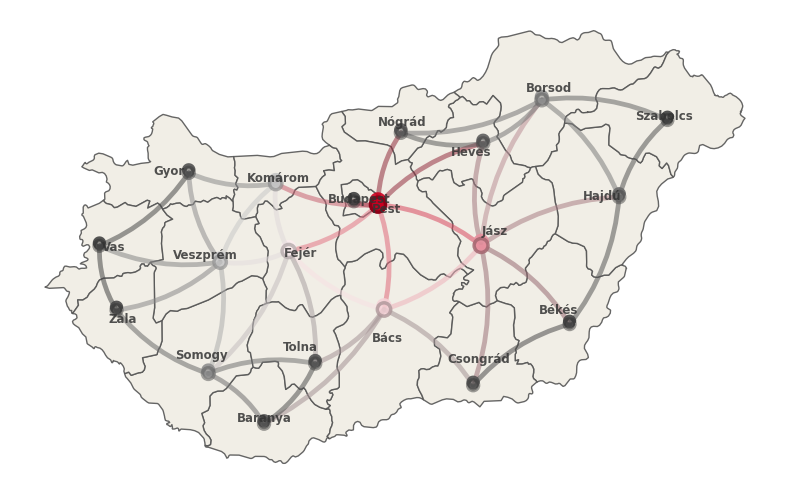

In [ ]:
# -*- coding: utf-8 -*-
"""
Classe HungaryNetwork:
- Carrega o mapa base da Hungria
- Calibra e plota automaticamente uma rede (Gephi)
- Ajusta nós aos centróides dos condados
- Aplica estilo TP1 (Gephi)
- Exibe distribuição de graus com seaborn
"""

class HungaryNetwork:
    def __init__(self, geojson_path, graph_path):
        """Inicializa com caminhos do mapa base e do arquivo GraphML."""
        self.geojson_path = geojson_path
        self.graph_path = graph_path
        self.gdf_clean = None
        self.hungary_shape = None
        self.G = None
        self.G_original = None
        self.r = None
        self.pos = None
        self.node_sizes = None
        self.node_colors = None
        self.border_colors = None
        self.edge_colors = None
        self.edge_widths = None
        self.node_alpha = None

    # ============================================================
    # 1️⃣ Mapa base
    # ============================================================
    def load_and_prepare_map(self):
        """Carrega o mapa da Hungria e combina pequenas cidades com condados."""
        print("📍 Carregando mapa base da Hungria...")
        gdf = gpd.read_file(self.geojson_path).to_crs(epsg=23700)
        nomes = [
            "Baranya", "Békéscsaba", "Békés", "Bács-Kiskun", "Budapest",
            "Borsod-Abaúj-Zemplén", "Csongrád", "Debrecen", "Dunaújváros",
            "Eger", "Érd", "Fejér", "Gyor-Moson-Sopron", "Gyôr",
            "Hajdú-Bihar", "Heves", "Hódmezôvásárhely", "Jász-Nagykun-Szolnok",
            "Komárom-Esztergom", "Kecskemét", "Kaposvár", "Miskolc",
            "Nagykanizsa", "Nógrád", "Nyíregyháza", "Pest", "Pécs",
            "Szeged", "Székesfehérvár", "Szombathely", "Szolnok",
            "Sopron", "Somogy", "Szekszárd", "Salgótarján",
            "Szabolcs-Szatmár-Bereg", "Tatabánya", "Tolna", "Vas",
            "Veszprém", "Zala", "Zalaegerszeg"
        ]
        gdf = gdf[gdf["name"].isin(nomes)].reset_index(drop=True)
        gdf["geometry"] = gdf.buffer(0)

        # Combina municípios pequenos com condados maiores
        assignments = {}
        for i, row_i in gdf.iterrows():
            name_i = row_i["name"]
            geom_i = row_i.geometry
            area_i = geom_i.area
            if name_i == "Budapest":
                assignments[name_i] = name_i
                continue
            geom_buf = geom_i.buffer(1000)
            best_neighbor, best_contact = None, 0
            for j, row_j in gdf.iterrows():
                if i == j:
                    continue
                geom_j = row_j.geometry
                area_j = geom_j.area
                if geom_buf.intersects(geom_j) and area_j > area_i:
                    inter = geom_buf.intersection(geom_j)
                    contact_len = inter.length
                    if (area_i / area_j) <= 0.25 and contact_len > best_contact:
                        best_contact = contact_len
                        best_neighbor = row_j["name"]
            assignments[name_i] = best_neighbor if best_neighbor else name_i

        gdf["region_group"] = gdf["name"].map(assignments)
        self.gdf_clean = gdf.dissolve(by="region_group").reset_index()
        self.hungary_shape = unary_union(self.gdf_clean.geometry)
        print("✅ Mapa processado com sucesso!")

    # ============================================================
    # 2️⃣ Rede
    # ============================================================
    def load_network(self):
        """Carrega a rede GraphML exportada do Gephi."""
        print("🔗 Carregando rede GraphML...")
        self.G = nx.read_graphml(self.graph_path)
        self.G_original = self.G
        self.r = nx.degree_assortativity_coefficient(self.G_original)
        print(nx.degree_assortativity_coefficient(self.G_original))
        print(f"✅ Rede carregada: {len(self.G.nodes())} nós, {len(self.G.edges())} arestas.")

    def calibrate_network(self):
        """Otimiza a escala e deslocamento da rede sobre o mapa."""
        def score_alignment(scale, offset_x, offset_y):
            points = [
                Point(scale * float(d["x"]) + offset_x, scale * float(d["y"]) + offset_y)
                for _, d in self.G.nodes(data=True)
            ]
            inside = sum(self.hungary_shape.contains(p) for p in points)
            ratio_inside = inside / len(points)
            x_coords, y_coords = zip(*[(p.x, p.y) for p in points])
            spread_penalty = np.std(x_coords) * np.std(y_coords)
            return ratio_inside / (1 + spread_penalty * 1e-10)

        print("⚙️ Calibrando posição da rede...")
        scales = np.linspace(4500, 6000, 6)
        offset_xs = np.linspace(600000, 660000, 7)
        offset_ys = np.linspace(180000, 240000, 7)
        best_params, best_score = None, -1

        for s in tqdm(scales):
            for ox in offset_xs:
                for oy in offset_ys:
                    sc = score_alignment(s, ox, oy)
                    if sc > best_score:
                        best_score = sc
                        best_params = (s, ox, oy)

        scale, offset_x, offset_y = best_params
        print(f"✅ Melhor ajuste: scale={scale:.1f}, offset_x={offset_x:.1f}, offset_y={offset_y:.1f}")

        self.pos = {
            n: (scale * float(d["x"]) + offset_x, scale * float(d["y"]) + offset_y)
            for n, d in self.G.nodes(data=True)
        }

    def adjust_nodes_to_centroids(self, alpha=0.35):
        """Move nós parcialmente em direção ao centróide mais próximo."""
        centroid_map = {row["region_group"]: row.geometry.centroid for _, row in self.gdf_clean.iterrows()}
        def nearest_centroid(x, y):
            pt = Point(x, y)
            best_c = min(centroid_map.values(), key=lambda c: pt.distance(c))
            return best_c
        self.pos = {
            n: (
                (1 - alpha) * x + alpha * nearest_centroid(x, y).x,
                (1 - alpha) * y + alpha * nearest_centroid(x, y).y,
            )
            for n, (x, y) in self.pos.items()
        }

    # ============================================================
    # 3️⃣ Estilo e plot
    # ============================================================
    def apply_style(self):
        """Configura esquema de cores e tamanhos (Gephi TP1)."""
        print("🎨 Aplicando estilo TP1 (Gephi)...")
        bet = nx.get_node_attributes(self.G, "betweenness_centrality")
        if not bet:
            bet = {n: 1.0 for n in self.G.nodes()}
        bmin, bmax = min(bet.values()), max(bet.values())

        size_min, size_max = 5, 10
        self.node_sizes = [
            300 * (size_min + (size_max - size_min) * (bet[n] - bmin) / (bmax - bmin + 1e-9))
            for n in self.G.nodes()
        ]
        self.node_alpha = {
            n: 0.45 + 0.55 * (bet[n] - bmin) / (bmax - bmin + 1e-9)
            for n in self.G.nodes()
        }

        def darken_color(rgb, f=0.7):
            return tuple(max(0, c * f) for c in rgb)

        self.node_colors, self.border_colors = [], []
        for _, d in self.G.nodes(data=True):
            rgb = (d.get("r", 180) / 255, d.get("g", 60) / 255, d.get("b", 60) / 255)
            self.node_colors.append(rgb)
            self.border_colors.append(darken_color(rgb))

        edge_w = nx.get_edge_attributes(self.G, "weight")
        if not edge_w:
            edge_w = {e: 1.0 for e in self.G.edges()}
        w_min, w_max = min(edge_w.values()), max(edge_w.values())

        self.edge_colors, self.edge_widths = {}, {}
        for (u, v), w in edge_w.items():
            cu = np.array(self.node_colors[list(self.G.nodes()).index(u)])
            cv = np.array(self.node_colors[list(self.G.nodes()).index(v)])
            mix = tuple(np.clip((cu + cv) / 2, 0, 1))
            self.edge_colors[(u, v)] = mix

            if abs(w_max - w_min) < 1e-9:
                self.edge_widths[(u, v)] = 1.5
            else:
                self.edge_widths[(u, v)] = 0.6 + 2.8 * (w - w_min) / (w_max - w_min)

        if abs(w_max - w_min) < 1e-9:
            print("⚠️  Todas as arestas têm o mesmo peso — espessura padrão aplicada.")
        print("✅ Estilo aplicado.")

    def plot_network(self, output="mapa_hungria.pdf", ax=None):
        """Plota a rede sobre o mapa base com barra lateral Gephi (preto→branco→vermelho #ca0323)."""

        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 6))
        else:
            fig = ax.figure

        ax.set_rasterization_zorder(2)

        bet = nx.get_node_attributes(self.G, "betweenness_centrality")
        if not bet:
            bet = {n: 1.0 for n in self.G.nodes()}
        values = np.array(list(bet.values()))
        vmin, vmax = values.min(), values.max()

        norm = mcolors.Normalize(vmin=0.0, vmax=1.0)

        gephi_tp1_colors = [
            (0.0, 0.0, 0.0),
            (1.0, 1.0, 1.0),
            (0.79, 0.01, 0.14)
        ]
        cmap = mcolors.LinearSegmentedColormap.from_list("gephi_tp1", gephi_tp1_colors, N=256)
        self.cmap = cmap

        self.gdf_clean.plot(ax=ax, color="#f0ede4", edgecolor="#555", linewidth=1.0, alpha=0.9)

        for (u, v) in self.G.edges():
            x1, y1 = self.pos[u]
            x2, y2 = self.pos[v]
            color, lw = self.edge_colors[(u, v)], 2.3 * self.edge_widths[(u, v)]
            if u == v:
                r = np.sqrt(self.node_sizes[list(self.G.nodes()).index(u)]) * 160
                loop = Arc((x1, y1 + r / 3), r, r, theta1=0, theta2=320,
                          lw=lw, color=color, alpha=0.9, capstyle='round')
                ax.add_patch(loop)
                continue
            ctrl_x, ctrl_y = (x1 + x2) / 2 - 0.15 * (y2 - y1), (y1 + y2) / 2 + 0.15 * (x2 - x1)
            path = Path([(x1, y1), (ctrl_x, ctrl_y), (x2, y2)],
                        [Path.MOVETO, Path.CURVE3, Path.CURVE3])
            ax.add_patch(PathPatch(path, facecolor="none", edgecolor=color,
                                  lw=lw, alpha=0.55, capstyle='round'))

        for i, (n, (x, y)) in enumerate(self.pos.items()):
            circle = plt.Circle((x, y), radius=np.sqrt(self.node_sizes[i]) * 100,
                                facecolor=self.node_colors[i], edgecolor=self.border_colors[i],
                                lw=2.5, alpha=self.node_alpha[n])
            ax.add_patch(circle)

        for _, row in self.gdf_clean.iterrows():
            c = row.geometry.centroid
            ax.text(c.x, c.y, row["region_group"].split("-")[0],
                    ha="center", va="center", fontsize=8.5, fontweight="bold",
                    color="#333", alpha=0.85, zorder=10)

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])

        #cbar = plt.colorbar(
        #    sm,
        #    ax=ax,
        #    orientation="vertical",
        #    fraction=0.045,
        #    pad=0.015,
        #)

        #cbar.outline.set_visible(False)

        #for spine in cbar.ax.spines.values():
        #    spine.set_visible(False)

        #cbar.ax.tick_params(
        #    labelsize=14,
        #    length=4,
        #    width=0,
        #)

        #cbar.ax.set_ylabel(
        #    r"$b_i$",
        #    fontsize=14,
        #    labelpad=6,
        #)

        ax.set_aspect("equal")

        #fig.suptitle("a) Geographical Configuration", fontsize=16, y=1.02)

        ax.axis("off")
        fig.tight_layout()
        fig.savefig(output, bbox_inches="tight", dpi=300)

        if ax is None:
            plt.show()

        print(f"✅ Mapa salvo em {output}")

        return ax

# ============================================================
# ✅ Exemplo de uso
# ============================================================
if __name__ == "__main__":
    net = HungaryNetwork("/content/hu.json", "/content/base_graph_ChickenpoxHungary.graphml")
    net.load_and_prepare_map()
    net.load_network()
    net.calibrate_network()
    net.adjust_nodes_to_centroids(alpha=0.35)
    net.apply_style()
    #net.plot_all_2x2()
    net.plot_network("mapa_hungria.pdf")
    #net.plot_degree_distribution(bins=7)
    #net.plot_degree_correlation_matrix()
    #net.plot_robustness()

# WikiMath Dataset

In [ ]:
!wget "https://raw.githubusercontent.com/gabrielxcosta/PCC121---Complex-Networks/main/Detec%C3%A7%C3%A3o%20de%20Comunidades/snapshot_001_WikiMath.graphml" -O snapshot_001_WikiMath.graphml

--2026-04-10 20:18:13--  https://raw.githubusercontent.com/gabrielxcosta/PCC121---Complex-Networks/main/Detec%C3%A7%C3%A3o%20de%20Comunidades/snapshot_001_WikiMath.graphml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2266764 (2.2M) [text/plain]
Saving to: ‘snapshot_001_WikiMath.graphml’

snapshot_001_WikiMa 100%[===================>]   2.16M  --.-KB/s    in 0.06s   

2026-04-10 20:18:13 (35.8 MB/s) - ‘snapshot_001_WikiMath.graphml’ saved [2266764/2266764]



🔗 Carregando rede WikiMath...
✅ 1068 nós, 27079 arestas
🎨 Estilo TP1 aplicado.


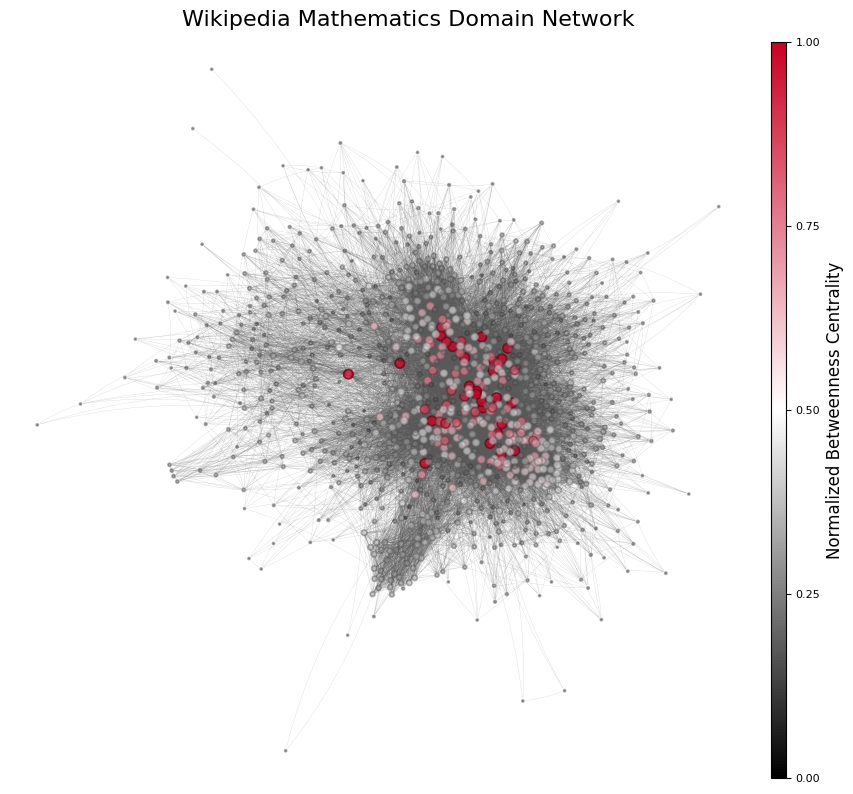

✅ Figure saved as wikimath_network.pdf


In [ ]:
# -*- coding: utf-8 -*-
"""
Classe WikiMathNetwork:
- Carrega o grafo WikiMath
- Aplica layout e estilo TP1 (Gephi)
- Gera o plot com barra lateral Gephi (preto→branco→vermelho)
- Exibe distribuição de graus com seaborn
"""

# ============================================================
# 🔧 Parâmetros visuais (mesmo padrão Hungary)
# ============================================================
FIGSIZE = (10, 8)
SEED, K, ITER = 42, 0.35, 140
Q_NODE = (0.02, 0.98)
Q_EDGE = 0.92
SIZE_MIN, SIZE_MAX = 5, 100
EDGE_BASE = (0.35, 0.35, 0.35, 0.16)
EDGE_TOP  = (0.35, 0.35, 0.35, 0.38)
EDGE_LW_MIN, EDGE_LW_MAX = 0.025, 0.25
RAD_BASE, RAD_SCALE = 0.06, 0.10
BORDER_DARKEN = 0.55

# 🎨 Colormap Gephi TP1 (preto → branco → vermelho #ca0323)
GEPHI_TP1_COLORS = [
    (0.0, 0.0, 0.0),      # preto
    (1.0, 1.0, 1.0),      # branco
    (0.79, 0.01, 0.14)    # vermelho #ca0323
]
GEOPHI_CMAP = colors.LinearSegmentedColormap.from_list("gephi_tp1", GEPHI_TP1_COLORS, N=256)


class WikiMathNetwork:
    def __init__(self, graph_path):
        """Inicializa a classe com o caminho do GraphML."""
        self.graph_path = graph_path
        self.G = None
        self.pos = None

    # ============================================================
    # 🔹 Funções auxiliares
    # ============================================================
    def normalize_pos(self, pos):
        xs = np.array([p[0] for p in pos.values()])
        ys = np.array([p[1] for p in pos.values()])
        x0, x1 = xs.min(), xs.max()
        y0, y1 = ys.min(), ys.max()
        sx, sy = (x1 - x0) or 1.0, (y1 - y0) or 1.0
        return {n: ((x - x0) / sx, (y - y0) / sy) for n, (x, y) in pos.items()}

    def clip_scale(self, arr, q_lo, q_hi, out_min=0.0, out_max=1.0):
        a = np.array(arr, float)
        lo, hi = np.quantile(a, q_lo), np.quantile(a, q_hi)
        a = np.clip(a, lo, hi)
        if hi - lo < 1e-12:
            return np.full_like(a, (out_min + out_max) / 2.0)
        return out_min + (a - lo) * (out_max - out_min) / (hi - lo)

    def darken(self, rgb, f=BORDER_DARKEN):
        return tuple(max(0.0, c * f) for c in rgb)

    # ============================================================
    # 1️⃣ Carregar rede
    # ============================================================
    def load_network(self):
        print("🔗 Carregando rede WikiMath...")
        self.G = nx.read_graphml(self.graph_path)
        print(f"✅ {self.G.number_of_nodes()} nós, {self.G.number_of_edges()} arestas")
        self.pos = self.normalize_pos(nx.spring_layout(self.G, seed=SEED, k=K, iterations=ITER))

    # ============================================================
    # 2️⃣ Aplicar estilo Gephi
    # ============================================================
    def apply_style(self):
        """Configura cores, tamanhos e espessuras conforme Gephi TP1."""
        nodes = list(self.G.nodes())
        deg = np.array([self.G.degree(n) for n in nodes], float)
        deg01 = self.clip_scale(deg, *Q_NODE, 0.0, 1.0)

        self.area = SIZE_MIN + (SIZE_MAX - SIZE_MIN) * deg01
        self.alpha_nodes = 0.30 + 0.45 * deg01

        # aplica cmap Gephi TP1 diretamente aos nós
        self.face_colors = [GEOPHI_CMAP(t) for t in deg01]
        self.border_colors = [self.darken(fc[:3]) for fc in self.face_colors]

        w_attr = nx.get_edge_attributes(self.G, "weight")
        if not w_attr:
            w_attr = {e: 1.0 for e in self.G.edges()}
        w = np.array([w_attr[e] for e in self.G.edges()], float)
        self.w_scaled = self.clip_scale(w, 0.05, 0.95, EDGE_LW_MIN, EDGE_LW_MAX)
        thr = np.quantile(w, Q_EDGE)

        edges = list(self.G.edges())
        self.edges_base = [(e, lw) for e, lw, ww in zip(edges, self.w_scaled, w) if ww < thr]
        self.edges_top  = [(e, lw) for e, lw, ww in zip(edges, self.w_scaled, w) if ww >= thr]
        print("🎨 Estilo TP1 aplicado.")

    # ============================================================
    # 3️⃣ Plot principal
    # ============================================================
    def plot_network(self, output="wikimath_network.pdf"):
        """Plots the WikiMath network in Gephi TP1 style (black→white→red)."""
        fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)
        fig.suptitle("Wikipedia Mathematics Domain Network", fontsize=16, y=1.02)

        def draw_arc(u, v, lw, col, a):
            x1, y1 = self.pos[u]
            x2, y2 = self.pos[v]
            if u == v:
                i = list(self.G.nodes()).index(u)
                r = np.sqrt(self.area[i]) * 0.0022
                ax.add_patch(Arc((x1, y1 + r / 3), r, r, theta1=0, theta2=320,
                                 lw=lw, color=col, alpha=a, capstyle="round", zorder=1))
                return
            L = np.hypot(x2 - x1, y2 - y1)
            rad = np.clip(RAD_BASE + RAD_SCALE * L, 0.02, 0.20)
            sgn = 1 if (hash(u) ^ hash(v)) & 1 else -1
            rad *= sgn
            patch = FancyArrowPatch(
                (x1, y1), (x2, y2),
                connectionstyle=f"arc3,rad={rad}",
                arrowstyle="-",
                mutation_scale=1.0,
                lw=lw, color=col, alpha=a,
                zorder=1, capstyle="round", joinstyle="round"
            )
            ax.add_patch(patch)

        # --- Edges ---
        for (u, v), lw in self.edges_base:
            draw_arc(u, v, lw, EDGE_BASE[:3], EDGE_BASE[3])
        for (u, v), lw in self.edges_top:
            draw_arc(u, v, lw * 1.10, EDGE_TOP[:3], EDGE_TOP[3])

        # --- Nodes ---
        for i, n in enumerate(self.G.nodes()):
            x, y = self.pos[n]
            r = np.sqrt(self.area[i]) * 0.0007
            ax.add_patch(plt.Circle((x, y), r,
                                    facecolor=self.face_colors[i],
                                    edgecolor=self.border_colors[i],
                                    lw=1.2, alpha=self.alpha_nodes[i], zorder=2))

        ax.set_xlim(-0.04, 1.04)
        ax.set_ylim(-0.04, 1.04)
        ax.set_aspect("equal")
        ax.axis("off")

        # --- Smaller vertical colorbar (Gephi TP1) ---
        norm = colors.Normalize(vmin=0.0, vmax=1.0)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="2.0%", pad=0.25)
        cb = fig.colorbar(ScalarMappable(norm=norm, cmap=GEOPHI_CMAP),
                          cax=cax, orientation="vertical", fraction=0.03)
        cb.set_label("Normalized Betweenness Centrality", fontsize=12)
        cb.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
        cb.ax.tick_params(labelsize=8)

        plt.savefig(output, bbox_inches="tight", dpi=350)
        plt.show()
        print(f"✅ Figure saved as {output}")

    def plot_network(self, output="wikimath_network.pdf"):
        """Plots the WikiMath network in Gephi TP1 style (black→white→red)."""
        # --- Layout sem 'constrained_layout' ---
        fig, ax = plt.subplots(figsize=FIGSIZE)
        ax.set_rasterization_zorder(2)
        fig.suptitle("Wikipedia Mathematics Domain Network", fontsize=16, y=0.98)

        def draw_arc(u, v, lw, col, a):
            x1, y1 = self.pos[u]
            x2, y2 = self.pos[v]
            if u == v:
                i = list(self.G.nodes()).index(u)
                r = np.sqrt(self.area[i]) * 0.0022
                ax.add_patch(Arc((x1, y1 + r / 3), r, r, theta1=0, theta2=320,
                                lw=lw, color=col, alpha=a, capstyle="round", zorder=1))
                return
            L = np.hypot(x2 - x1, y2 - y1)
            rad = np.clip(RAD_BASE + RAD_SCALE * L, 0.02, 0.20)
            sgn = 1 if (hash(u) ^ hash(v)) & 1 else -1
            rad *= sgn
            patch = FancyArrowPatch(
                (x1, y1), (x2, y2),
                connectionstyle=f"arc3,rad={rad}",
                arrowstyle="-",
                mutation_scale=1.0,
                lw=lw, color=col, alpha=a,
                zorder=1, capstyle="round", joinstyle="round"
            )
            ax.add_patch(patch)

        # --- Edges ---
        for (u, v), lw in self.edges_base:
            draw_arc(u, v, lw, EDGE_BASE[:3], EDGE_BASE[3])
        for (u, v), lw in self.edges_top:
            draw_arc(u, v, lw * 1.10, EDGE_TOP[:3], EDGE_TOP[3])

        # --- Nodes ---
        for i, n in enumerate(self.G.nodes()):
            x, y = self.pos[n]
            r = np.sqrt(self.area[i]) * 0.0007
            ax.add_patch(plt.Circle((x, y), r,
                                    facecolor=self.face_colors[i],
                                    edgecolor=self.border_colors[i],
                                    lw=1.2, alpha=self.alpha_nodes[i], zorder=2))

        ax.set_xlim(-0.04, 1.04)
        ax.set_ylim(-0.04, 1.04)
        ax.set_aspect("equal")
        ax.axis("off")

        # --- Smaller vertical colorbar (Gephi TP1) ---
        norm = colors.Normalize(vmin=0.0, vmax=1.0)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="2.0%", pad=0.25)
        cb = fig.colorbar(ScalarMappable(norm=norm, cmap=GEOPHI_CMAP),
                          cax=cax, orientation="vertical", fraction=0.03)
        cb.set_label("Normalized Betweenness Centrality", fontsize=12)
        cb.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
        cb.ax.tick_params(labelsize=8)

        # --- Ajuste fino para preservar layout idêntico ---
        plt.subplots_adjust(top=0.94, right=0.96, left=0.02, bottom=0.02)

        # --- Exibir e salvar ---
        plt.show()
        fig.savefig(output, dpi=350, bbox_inches="tight", pad_inches=0.1)
        print(f"✅ Figure saved as {output}")


    # ============================================================
    # 4️⃣ Degree distribution
    # ============================================================
    def plot_degree_distribution(self, palette="mako", bins=15):
        """Plots the network degree distribution using seaborn."""
        degrees = np.array([d for _, d in self.G.degree()])
        mean_deg = np.mean(degrees)
        sns.set_theme(style="whitegrid", palette=palette)
        plt.figure(figsize=(7, 4))
        color = (0.25, 0.25, 0.25)
        color_mean = (0.88, 0.41, 0.48)

        sns.histplot(degrees, bins=bins, stat="density",
                     color=color, alpha=0.5, label="Histogram")
        sns.kdeplot(degrees, bw_adjust=0.6, color=color,
                    lw=2.2, label="Density (KDE)")
        plt.axvline(mean_deg, color=color_mean, ls="--",
                    lw=1.4, label=f"Mean = {mean_deg:.2f}")

        plt.title("Degree Distribution - WikiMath Network", fontsize=12)
        plt.xlabel("Degree (number of connections)")
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()

# ============================================================
# ✅ Exemplo de uso
# ============================================================
if __name__ == "__main__":
    net = WikiMathNetwork("/content/snapshot_001_WikiMath.graphml")
    net.load_network()
    net.apply_style()
    net.plot_network("wikimath_network.pdf")
    #net.plot_degree_distribution(bins=7)

# Montevideo Bus Dataset

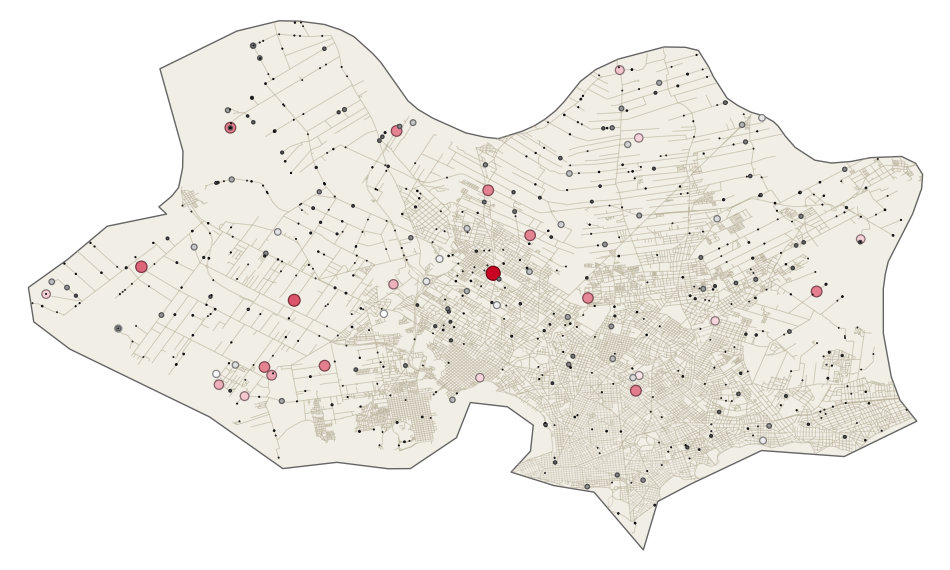

In [ ]:
# -*- coding: utf-8 -*-
import geopandas as gpd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import osmnx as ox

from shapely.geometry import Point
from shapely.ops import unary_union

FIGSIZE = (12, 8)
BORDER_DARKEN = 0.55

GEPHI_TP1_COLORS = [
    (0.0, 0.0, 0.0),
    (1.0, 1.0, 1.0),
    (0.79, 0.01, 0.14)
]
GEPHI_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "gephi_tp1", GEPHI_TP1_COLORS, N=256
)


class MontevideoNetwork:
    def __init__(self, geojson_path, graph_path):
        self.geojson_path = geojson_path
        self.graph_path = graph_path
        self.gdf_map = None
        self.city_shape = None
        self.G = None
        self.pos = None

    def load_map(self):
        gdf = gpd.read_file(self.geojson_path)
        gdf = gdf[gdf["name"] == "Montevideo"]
        gdf = gdf.to_crs(epsg=4326)
        self.gdf_map = gdf
        self.city_shape = unary_union(gdf.geometry)

    def load_network(self):
        self.G = nx.read_graphml(self.graph_path)
        self.pos = {
            n: (float(d.get("lon_road", d.get("Longitude", 0))),
                float(d.get("lat_road", d.get("Latitude", 0))))
            for n, d in self.G.nodes(data=True)
        }

    def clip_network(self):
        nodes_to_keep = []
        for n, (x, y) in self.pos.items():
            p = Point(x, y)
            if self.city_shape.contains(p):
                nodes_to_keep.append(n)

        self.G = self.G.subgraph(nodes_to_keep).copy()
        self.pos = {n: self.pos[n] for n in nodes_to_keep}

    def plot_gephi_tp1_with_map(self, ax=None, title=None):

        if ax is None:
            fig, ax = plt.subplots(figsize=FIGSIZE)
        else:
            fig = ax.figure

        ax.set_rasterization_zorder(2)

        bet = nx.betweenness_centrality(self.G, normalized=True)
        bet_vals = np.array(list(bet.values()))
        bet_norm = (bet_vals - bet_vals.min()) / (bet_vals.max() - bet_vals.min() + 1e-9)
        bet_norm_dict = {n: v for n, v in zip(self.G.nodes(), bet_norm)}

        cmap = GEPHI_CMAP
        norm = mcolors.Normalize(vmin=0.0, vmax=1.0)

        # mapa
        self.gdf_map.plot(
            ax=ax,
            color="#f0ede4",
            edgecolor="#555",
            linewidth=1.0,
            alpha=0.9,
            zorder=0
        )

        # ruas
        G_roads = ox.graph_from_place("Montevideo, Uruguay", network_type="drive")
        edges = ox.graph_to_gdfs(G_roads, nodes=False)
        edges_clipped = gpd.clip(edges, self.gdf_map)

        edges_clipped.plot(
            ax=ax,
            linewidth=0.6,
            color="#b5ad95",
            alpha=0.35,
            zorder=1
        )

        # nós
        node_colors = {n: cmap(norm(bet_norm_dict[n])) for n in self.G.nodes()}

        min_size, max_size = 0.05, 1.2
        node_sizes = min_size + (max_size - min_size) * bet_norm

        for (n, (x, y)), s in zip(self.pos.items(), node_sizes):
            c = node_colors[n]
            bc = tuple(np.array(c[:3]) * BORDER_DARKEN)

            ax.add_patch(
                plt.Circle(
                    (x, y),
                    radius=s * 0.0025,
                    facecolor=c,
                    edgecolor=bc,
                    lw=0.9,
                    zorder=2
                )
            )

        # ✅ FIX PRINCIPAL: usar bounds do mapa (não da rede)
        xmin, ymin, xmax, ymax = self.gdf_map.total_bounds

        pad_x = (xmax - xmin) * 0.02
        pad_y = (ymax - ymin) * 0.02

        ax.set_xlim(xmin - pad_x, xmax + pad_x)
        ax.set_ylim(ymin - pad_y, ymax + pad_y)

        try:
            ax.set_aspect("equal")
        except:
            pass

        if title is not None:
            ax.set_title(title, fontsize=16)

        ax.axis("off")

        return ax


if __name__ == "__main__":
    net = MontevideoNetwork(
        geojson_path="/content/mv.json",
        graph_path="/content/base_graph_MontevideoBus.graphml"
    )

    net.load_map()
    net.load_network()
    net.clip_network()
    net.plot_gephi_tp1_with_map()

# England Covid Dataset

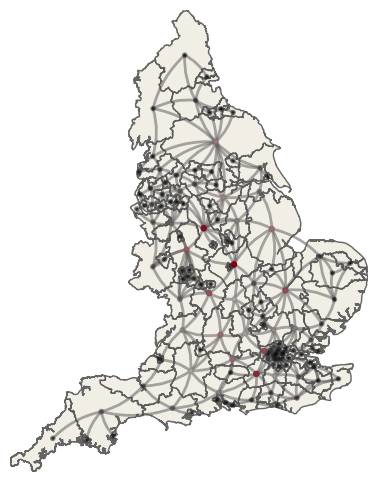

In [ ]:
# -*- coding: utf-8 -*-

import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Arc
import matplotlib.colors as colors
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1 import make_axes_locatable

FIGSIZE = (10, 8)
Q_NODE = (0.05, .9)
SIZE_MIN, SIZE_MAX = 5, 100
EDGE_LW_MIN, EDGE_LW_MAX = 0.075, .75
BORDER_DARKEN = 0.55

GEPHI_TP1_COLORS = [
    (0.0, 0.0, 0.0),
    (1.0, 1.0, 1.0),
    (0.79, 0.01, 0.14)
]
GEOPHI_CMAP = colors.LinearSegmentedColormap.from_list("gephi_tp1", GEPHI_TP1_COLORS, N=256)


class EnglandCovidNetwork:
    def __init__(self, geojson_path):
        self.geojson_path = geojson_path

    def clip_scale(self, arr, q_lo, q_hi, out_min=0.0, out_max=1.0):
        a = np.array(arr, float)
        lo, hi = np.quantile(a, q_lo), np.quantile(a, q_hi)
        a = np.clip(a, lo, hi)
        if hi - lo < 1e-12:
            return np.full_like(a, (out_min + out_max) / 2.0)
        return out_min + (a - lo) * (out_max - out_min) / (hi - lo)

    def darken(self, rgb, f=BORDER_DARKEN):
        return tuple(max(0.0, c * f) for c in rgb)

    def load_and_prepare_map(self):
        gdf = gpd.read_file(self.geojson_path)

        lat_UKC21 = gdf.loc[gdf["nuts318cd"] == "UKC21", "lat"].values[0]
        lat_UKD12 = gdf.loc[gdf["nuts318cd"] == "UKD12", "lat"].values[0]
        lat_cut = min(lat_UKC21, lat_UKD12)

        gdf_filtered = gdf[gdf["lat"] <= lat_cut]
        gdf_filtered = gdf_filtered[gdf_filtered["nuts318cd"] != "UKD11"]

        gdf_filtered = gdf_filtered[~gdf_filtered["nuts318cd"].isin([
            "UKN16","UKN10","UKN12","UKN11","UKN15","UKN14","UKN09","UKN08","UKN07",
            "UKG11","UKL21","UKL16","UKL23","UKL13","UKL12","UKL14","UKL18","UKL17","UKL24"
        ])]

        gdf_filtered = pd.concat([
            gdf_filtered,
            gdf[gdf["nuts318cd"].isin(["UKC14","UKC22","UKC21"])]
        ]).drop_duplicates().reset_index(drop=True)

        gdf_filtered = gdf_filtered.to_crs(epsg=3857)

        mainland = gdf_filtered.geometry.union_all()
        if mainland.geom_type == "MultiPolygon":
            mainland = max(mainland.geoms, key=lambda g: g.area)

        gdf_filtered["geometry"] = gdf_filtered.geometry.intersection(mainland)
        gdf_filtered = gdf_filtered[~gdf_filtered.geometry.is_empty].reset_index(drop=True)

        adj = gdf_filtered.geometry.apply(lambda geom: gdf_filtered.geometry.touches(geom))
        adj_matrix = adj.values.astype(int)

        G = nx.from_numpy_array(adj_matrix)

        components = list(nx.connected_components(G))
        largest = max(components, key=len)
        nodes = sorted(list(largest))

        gdf_filtered = gdf_filtered.iloc[nodes].reset_index(drop=True)
        G = nx.from_numpy_array(nx.to_numpy_array(G.subgraph(nodes)))

        centroids = gdf_filtered.geometry.centroid

        self.pos = {i: (centroids.iloc[i].x, centroids.iloc[i].y) for i in range(len(gdf_filtered))}
        self.G = G
        self.gdf_clean = gdf_filtered

    def apply_style(self):
        nodes = list(self.G.nodes())
        deg = np.array([self.G.degree(n) for n in nodes], float)
        deg01 = self.clip_scale(deg, *Q_NODE)

        self.area = SIZE_MIN + (SIZE_MAX - SIZE_MIN) * deg01
        self.alpha_nodes = 0.5 + 0.5 * deg01

        self.face_colors = [GEOPHI_CMAP(t) for t in deg01]
        self.border_colors = [self.darken(fc[:3]) for fc in self.face_colors]

        edges = list(self.G.edges())
        self.edge_widths = np.full(len(edges), 0.8)

    def plot_network(self, ax=None, title=None):

        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 6))
        else:
            fig = ax.figure

        ax.set_rasterization_zorder(2)

        bet = nx.betweenness_centrality(self.G, normalized=True)
        values = np.array(list(bet.values()))

        vmin, vmax = values.min(), values.max()
        bet_norm = {n: (bet[n] - vmin) / (vmax - vmin + 1e-9) for n in self.G.nodes()}

        norm = mcolors.Normalize(vmin=0.0, vmax=1.0)

        cmap = mcolors.LinearSegmentedColormap.from_list(
            "gephi_tp1",
            [
                (0.0, 0.0, 0.0),
                (1.0, 1.0, 1.0),
                (0.79, 0.01, 0.14)
            ],
            N=256
        )

        self.gdf_clean.plot(ax=ax, color="#f0ede4", edgecolor="#555", linewidth=1.0, alpha=0.9)

        nodes = list(self.G.nodes())

        node_sizes = [300 * (5 + 5 * bet_norm[n]) for n in nodes]
        node_alpha = {n: 0.45 + 0.55 * bet_norm[n] for n in nodes}

        node_colors = [cmap(bet_norm[n]) for n in nodes]
        border_colors = [(c[0]*0.6, c[1]*0.6, c[2]*0.6) for c in node_colors]

        for (u, v) in self.G.edges():
            x1, y1 = self.pos[u]
            x2, y2 = self.pos[v]

            cx = (x1 + x2) / 2 - 0.15 * (y2 - y1)
            cy = (y1 + y2) / 2 + 0.15 * (x2 - x1)

            path = Path(
                [(x1, y1), (cx, cy), (x2, y2)],
                [Path.MOVETO, Path.CURVE3, Path.CURVE3]
            )

            ax.add_patch(PathPatch(
                path,
                facecolor="none",
                edgecolor="#555",
                lw=2.0,
                alpha=0.5,
                capstyle='round'
            ))

        for i, n in enumerate(nodes):
            x, y = self.pos[n]

            circle = plt.Circle(
                (x, y),
                radius=np.sqrt(node_sizes[i]) * 80,
                facecolor=node_colors[i],
                edgecolor=border_colors[i],
                lw=2.0,
                alpha=node_alpha[n]
            )
            ax.add_patch(circle)

        xmin, ymin, xmax, ymax = self.gdf_clean.total_bounds

        cx = (xmin + xmax) / 2
        cy = (ymin + ymax) / 2

        w = (xmax - xmin)
        h = (ymax - ymin)

        ax.set_xlim(cx - w/2, cx + w/2)
        ax.set_ylim(cy - h/2, cy + h/2)

        ax.set_aspect("equal")

        if title is not None:
            ax.set_title(title, fontsize=16)

        ax.axis("off")

        return ax


if __name__ == "__main__":
    net = EnglandCovidNetwork(
        "/content/NUTS_Level_3_January_2018_GCB_in_the_United_Kingdom_2022_2478629265163298349.geojson"
    )
    net.load_and_prepare_map()
    net.apply_style()
    net.plot_network()

# All

In [ ]:
# -*- coding: utf-8 -*-

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1 import make_axes_locatable


class MultiDatasetPlot:

    def __init__(self, hungary, wikimath, montevideo, england):
        self.hungary = hungary
        self.wikimath = wikimath
        self.montevideo = montevideo
        self.england = england

        self.cmap = mcolors.LinearSegmentedColormap.from_list(
            "gephi_tp1",
            [
                (0.0, 0.0, 0.0),
                (1.0, 1.0, 1.0),
                (0.79, 0.01, 0.14)
            ],
            N=256
        )
        self.norm = mcolors.Normalize(vmin=0.0, vmax=1.0)

    def plot_all(self, output="multi_datasets.pdf"):

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        ax1, ax2 = axes[0]
        ax3, ax4 = axes[1]

        self.hungary.plot_network(ax=ax1)
        ax1.set_title("a) Chickenpox Hungary", fontsize=14)

        self.wikimath.plot_network(output=None)
        for artist in plt.gca().get_children():
            ax2.add_artist(artist)
        ax2.set_xlim(plt.gca().get_xlim())
        ax2.set_ylim(plt.gca().get_ylim())
        ax2.set_aspect("equal")
        ax2.axis("off")
        ax2.set_title("b) WikiMath", fontsize=14)
        plt.close()

        self.montevideo.plot_gephi_tp1_with_map(output=None)
        for artist in plt.gca().get_children():
            ax3.add_artist(artist)
        ax3.set_xlim(plt.gca().get_xlim())
        ax3.set_ylim(plt.gca().get_ylim())
        try:
            ax3.set_aspect("equal")
        except:
            pass
        ax3.axis("off")
        ax3.set_title("c) Montevideo Bus", fontsize=14)
        plt.close()

        self.england.plot_network(ax=ax4)
        ax4.set_title("d) England Covid", fontsize=14)

        sm = ScalarMappable(norm=self.norm, cmap=self.cmap)
        sm.set_array([])

        cbar = fig.colorbar(
            sm,
            ax=axes.ravel().tolist(),
            orientation="vertical",
            fraction=0.02,
            pad=0.02
        )

        cbar.outline.set_visible(False)
        for spine in cbar.ax.spines.values():
            spine.set_visible(False)

        cbar.ax.tick_params(labelsize=12)
        cbar.ax.set_ylabel(r"$b_i$", fontsize=14)

        for ax in axes.ravel():
            ax.axis("off")

        plt.tight_layout()
        plt.savefig(output, dpi=300, bbox_inches="tight")
        plt.show()

📍 Carregando mapa base da Hungria...
✅ Mapa processado com sucesso!
🔗 Carregando rede GraphML...
0.1471828864115707
✅ Rede carregada: 20 nós, 61 arestas.
⚙️ Calibrando posição da rede...


100%|██████████| 6/6 [00:00<00:00, 19.90it/s]


✅ Melhor ajuste: scale=4500.0, offset_x=660000.0, offset_y=200000.0
🎨 Aplicando estilo TP1 (Gephi)...
⚠️  Todas as arestas têm o mesmo peso — espessura padrão aplicada.
✅ Estilo aplicado.
✅ Mapa salvo em mapa_hungria.pdf


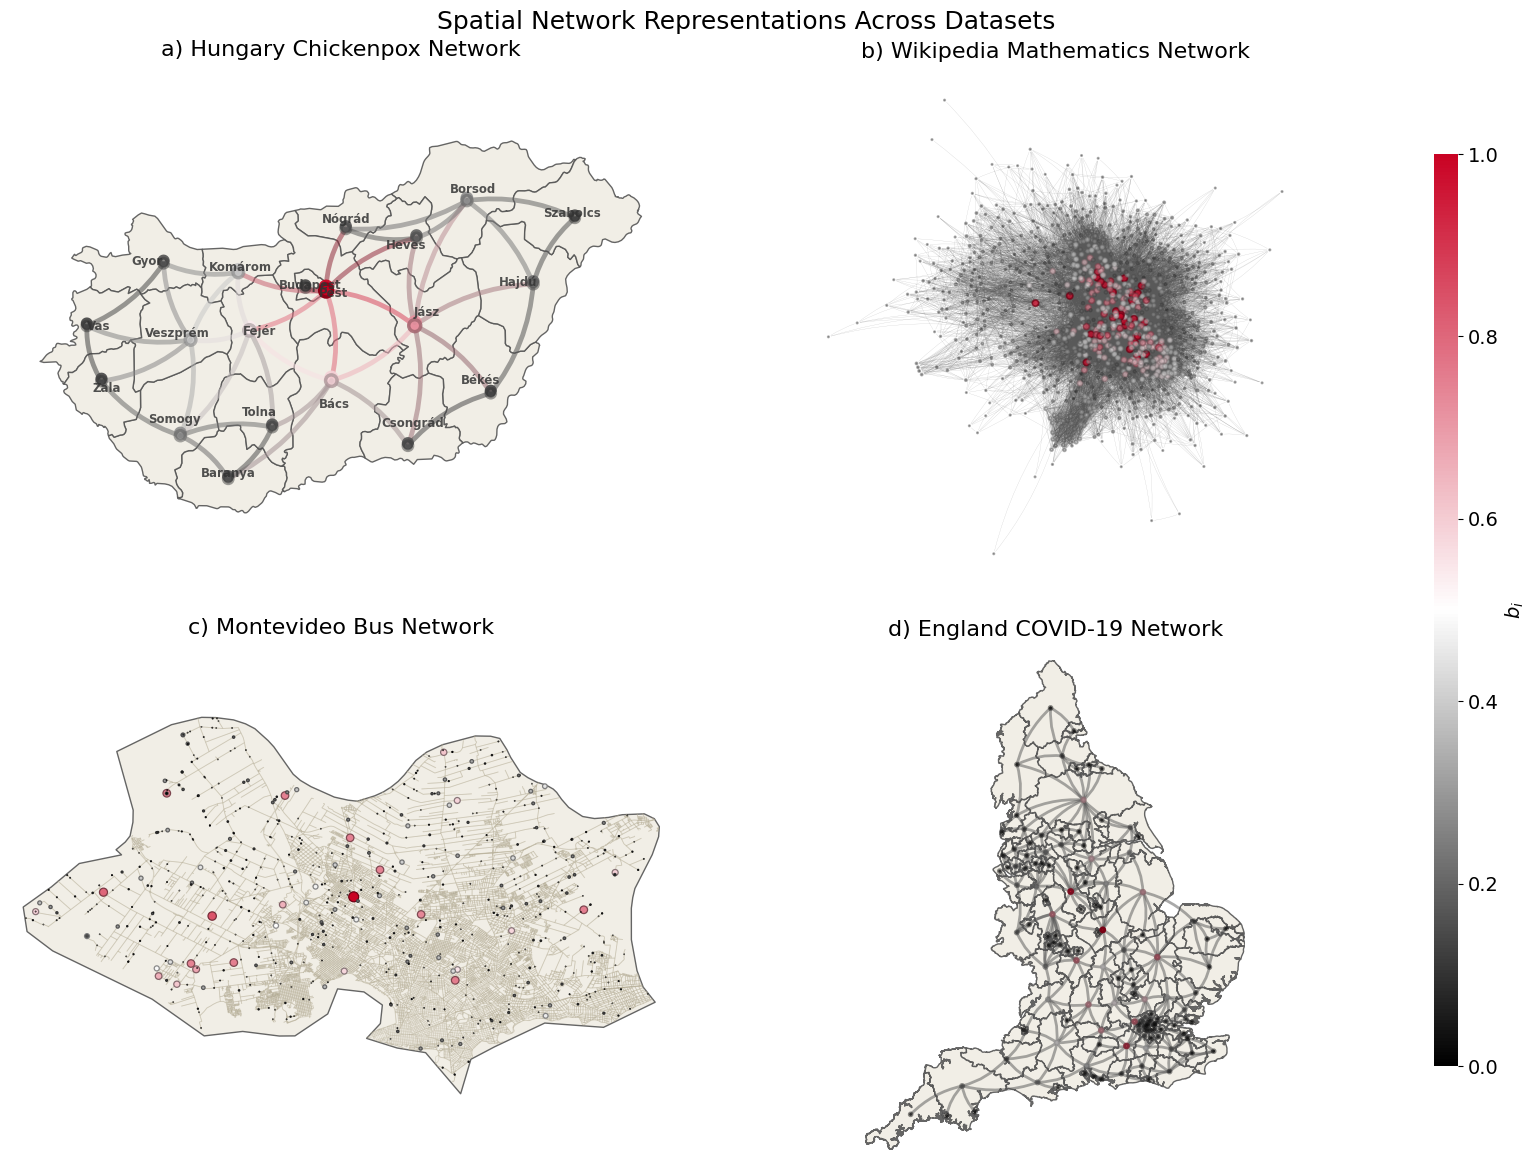

In [ ]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import osmnx as ox

from tqdm import tqdm
from shapely.geometry import Point
from shapely.ops import unary_union
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Arc, FancyArrowPatch, PathPatch
from matplotlib.path import Path

FIGSIZE_WIKIMATH = (10, 8)
FIGSIZE_MONTEVIDEO = (12, 8)

Q_NODE_WIKIMATH = (0.02, 0.98)
Q_EDGE_WIKIMATH = 0.92
SIZE_MIN_WIKIMATH, SIZE_MAX_WIKIMATH = 5, 100
EDGE_BASE_WIKIMATH = (0.35, 0.35, 0.35, 0.10)
EDGE_TOP_WIKIMATH = (0.35, 0.35, 0.35, 0.30)
EDGE_LW_MIN_WIKIMATH, EDGE_LW_MAX_WIKIMATH = 0.02, 0.20
RAD_BASE_WIKIMATH, RAD_SCALE_WIKIMATH = 0.04, 0.08

BORDER_DARKEN = 0.55

GEPHI_TP1_COLORS = [
    (0.0, 0.0, 0.0),
    (1.0, 1.0, 1.0),
    (0.79, 0.01, 0.14)
]
GEPHI_CMAP = mcolors.LinearSegmentedColormap.from_list("gephi_tp1", GEPHI_TP1_COLORS, N=256)


class WikiMathNetwork:

    def __init__(self, graph_path):
        self.graph_path = graph_path
        self.G = None
        self.pos = None
        self.area = None
        self.alpha_nodes = None
        self.face_colors = None
        self.border_colors = None
        self.edges_base = None
        self.edges_top = None

    def normalize_pos(self, pos):
        xs = np.array([p[0] for p in pos.values()])
        ys = np.array([p[1] for p in pos.values()])
        x0, x1 = xs.min(), xs.max()
        y0, y1 = ys.min(), ys.max()
        sx, sy = (x1 - x0) or 1.0, (y1 - y0) or 1.0
        return {n: ((x - x0) / sx, (y - y0) / sy) for n, (x, y) in pos.items()}

    def clip_scale(self, arr, q_lo, q_hi, out_min=0.0, out_max=1.0):
        a = np.array(arr, float)
        lo, hi = np.quantile(a, q_lo), np.quantile(a, q_hi)
        a = np.clip(a, lo, hi)
        if hi - lo < 1e-12:
            return np.full_like(a, (out_min + out_max) / 2.0)
        return out_min + (a - lo) * (out_max - out_min) / (hi - lo)

    def darken(self, rgb):
        return tuple(max(0.0, c * BORDER_DARKEN) for c in rgb)

    def load_network(self):
        self.G = nx.read_graphml(self.graph_path)
        self.pos = self.normalize_pos(nx.spring_layout(self.G, seed=42, k=0.25, iterations=80))

    def apply_style(self):
        nodes = list(self.G.nodes())

        deg = np.array([self.G.degree(n) for n in nodes], float)
        deg01 = self.clip_scale(deg, *Q_NODE_WIKIMATH)

        bet = nx.betweenness_centrality(self.G, normalized=True)
        bet_vals = np.array([bet[n] for n in nodes], float)
        bet_norm = self.clip_scale(bet_vals, 0.0, 1.0)

        self.area = SIZE_MIN_WIKIMATH + (SIZE_MAX_WIKIMATH - SIZE_MIN_WIKIMATH) * deg01
        self.alpha_nodes = 0.35 + 0.4 * deg01
        self.face_colors = [GEPHI_CMAP(v) for v in bet_norm]
        self.border_colors = [self.darken(c[:3]) for c in self.face_colors]

        w_attr = nx.get_edge_attributes(self.G, "weight")
        if not w_attr:
            w_attr = {e: 1.0 for e in self.G.edges()}

        w = np.array([w_attr[e] for e in self.G.edges()], float)
        w_scaled = self.clip_scale(w, 0.05, 0.95, EDGE_LW_MIN_WIKIMATH, EDGE_LW_MAX_WIKIMATH)
        thr = np.quantile(w, Q_EDGE_WIKIMATH)

        edges = list(self.G.edges())
        self.edges_base = [(e, lw) for e, lw, ww in zip(edges, w_scaled, w) if ww < thr]
        self.edges_top = [(e, lw) for e, lw, ww in zip(edges, w_scaled, w) if ww >= thr]

    def plot_network(self, ax):
        ax.set_rasterization_zorder(2)

        def draw_arc(u, v, lw, col, a):
            x1, y1 = self.pos[u]
            x2, y2 = self.pos[v]
            L = np.hypot(x2 - x1, y2 - y1)
            rad = np.clip(RAD_BASE_WIKIMATH + RAD_SCALE_WIKIMATH * L, 0.02, 0.15)
            sgn = 1 if (hash(u) ^ hash(v)) & 1 else -1
            patch = FancyArrowPatch(
                (x1, y1), (x2, y2),
                connectionstyle=f"arc3,rad={rad * sgn}",
                arrowstyle="-",
                lw=lw, color=col, alpha=a
            )
            ax.add_patch(patch)

        for (u, v), lw in self.edges_base:
            draw_arc(u, v, lw, EDGE_BASE_WIKIMATH[:3], EDGE_BASE_WIKIMATH[3])

        for (u, v), lw in self.edges_top:
            draw_arc(u, v, lw * 1.2, EDGE_TOP_WIKIMATH[:3], EDGE_TOP_WIKIMATH[3])

        for i, n in enumerate(self.G.nodes()):
            x, y = self.pos[n]
            r = np.sqrt(self.area[i]) * 0.00055
            ax.add_patch(plt.Circle((x, y), r,
                                    facecolor=self.face_colors[i],
                                    edgecolor=self.border_colors[i],
                                    lw=0.9,
                                    alpha=self.alpha_nodes[i]))

        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.set_aspect("equal")
        ax.axis("off")

FIGSIZE_WIKIMATH = (10, 8)

Q_NODE_WIKIMATH = (0.02, 0.98)
Q_EDGE_WIKIMATH = 0.92
SIZE_MIN_WIKIMATH, SIZE_MAX_WIKIMATH = 5, 100
EDGE_BASE_WIKIMATH = (0.35, 0.35, 0.35, 0.16)
EDGE_TOP_WIKIMATH  = (0.35, 0.35, 0.35, 0.38)
EDGE_LW_MIN_WIKIMATH, EDGE_LW_MAX_WIKIMATH = 0.025, 0.25
RAD_BASE_WIKIMATH, RAD_SCALE_WIKIMATH = 0.06, 0.10

BORDER_DARKEN = 0.55

GEPHI_TP1_COLORS = [
    (0.0, 0.0, 0.0),
    (1.0, 1.0, 1.0),
    (0.79, 0.01, 0.14)
]
GEPHI_CMAP = mcolors.LinearSegmentedColormap.from_list("gephi_tp1", GEPHI_TP1_COLORS, N=256)


class WikiMathNetwork:

    def __init__(self, graph_path):
        self.graph_path = graph_path
        self.G = None
        self.pos = None
        self.area = None
        self.alpha_nodes = None
        self.face_colors = None
        self.border_colors = None
        self.edges_base = None
        self.edges_top = None

    def normalize_pos(self, pos):
        xs = np.array([p[0] for p in pos.values()])
        ys = np.array([p[1] for p in pos.values()])
        x0, x1 = xs.min(), xs.max()
        y0, y1 = ys.min(), ys.max()
        sx, sy = (x1 - x0) or 1.0, (y1 - y0) or 1.0
        return {n: ((x - x0) / sx, (y - y0) / sy) for n, (x, y) in pos.items()}

    def clip_scale(self, arr, q_lo, q_hi, out_min=0.0, out_max=1.0):
        a = np.array(arr, float)
        lo, hi = np.quantile(a, q_lo), np.quantile(a, q_hi)
        a = np.clip(a, lo, hi)
        if hi - lo < 1e-12:
            return np.full_like(a, (out_min + out_max) / 2.0)
        return out_min + (a - lo) * (out_max - out_min) / (hi - lo)

    def darken(self, rgb):
        return tuple(max(0.0, c * BORDER_DARKEN) for c in rgb)

    def load_network(self):
        self.G = nx.read_graphml(self.graph_path)
        self.pos = self.normalize_pos(nx.spring_layout(self.G, seed=42, k=0.35, iterations=140))

    def apply_style(self):
        nodes = list(self.G.nodes())

        deg = np.array([self.G.degree(n) for n in nodes], float)
        deg01 = self.clip_scale(deg, *Q_NODE_WIKIMATH)

        self.area = SIZE_MIN_WIKIMATH + (SIZE_MAX_WIKIMATH - SIZE_MIN_WIKIMATH) * deg01
        self.alpha_nodes = 0.30 + 0.45 * deg01

        self.face_colors = [GEPHI_CMAP(t) for t in deg01]
        self.border_colors = [self.darken(fc[:3]) for fc in self.face_colors]

        w_attr = nx.get_edge_attributes(self.G, "weight")
        if not w_attr:
            w_attr = {e: 1.0 for e in self.G.edges()}

        w = np.array([w_attr[e] for e in self.G.edges()], float)
        w_scaled = self.clip_scale(w, 0.05, 0.95, EDGE_LW_MIN_WIKIMATH, EDGE_LW_MAX_WIKIMATH)
        thr = np.quantile(w, Q_EDGE_WIKIMATH)

        edges = list(self.G.edges())
        self.edges_base = [(e, lw) for e, lw, ww in zip(edges, w_scaled, w) if ww < thr]
        self.edges_top  = [(e, lw) for e, lw, ww in zip(edges, w_scaled, w) if ww >= thr]

    def plot_network(self, ax=None, title=None):

        if ax is None:
            fig, ax = plt.subplots(figsize=FIGSIZE_WIKIMATH)
        else:
            fig = ax.figure

        ax.set_rasterization_zorder(2)

        def draw_arc(u, v, lw, col, a):
            x1, y1 = self.pos[u]
            x2, y2 = self.pos[v]

            if u == v:
                i = list(self.G.nodes()).index(u)
                r = np.sqrt(self.area[i]) * 0.0022
                ax.add_patch(Arc((x1, y1 + r / 3), r, r,
                                 theta1=0, theta2=320,
                                 lw=lw, color=col, alpha=a,
                                 capstyle="round", zorder=1))
                return

            L = np.hypot(x2 - x1, y2 - y1)
            rad = np.clip(RAD_BASE_WIKIMATH + RAD_SCALE_WIKIMATH * L, 0.02, 0.20)
            sgn = 1 if (hash(u) ^ hash(v)) & 1 else -1
            rad *= sgn

            patch = FancyArrowPatch(
                (x1, y1), (x2, y2),
                connectionstyle=f"arc3,rad={rad}",
                arrowstyle="-",
                lw=lw, color=col, alpha=a,
                zorder=1, capstyle="round", joinstyle="round"
            )
            ax.add_patch(patch)

        for (u, v), lw in self.edges_base:
            draw_arc(u, v, lw, EDGE_BASE_WIKIMATH[:3], EDGE_BASE_WIKIMATH[3])

        for (u, v), lw in self.edges_top:
            draw_arc(u, v, lw * 1.10, EDGE_TOP_WIKIMATH[:3], EDGE_TOP_WIKIMATH[3])

        for i, n in enumerate(self.G.nodes()):
            x, y = self.pos[n]
            r = np.sqrt(self.area[i]) * 0.0007
            ax.add_patch(plt.Circle((x, y), r,
                                    facecolor=self.face_colors[i],
                                    edgecolor=self.border_colors[i],
                                    lw=1.2,
                                    alpha=self.alpha_nodes[i],
                                    zorder=2))

        ax.set_xlim(-0.04, 1.04)
        ax.set_ylim(-0.04, 1.04)
        ax.set_aspect("equal")
        ax.axis("off")

        if title is not None:
            ax.set_title(title, fontsize=16)

        return ax


class MultiDatasetPlot:

    def __init__(self, hungary, wikimath, montevideo, england):
        self.hungary = hungary
        self.wikimath = wikimath
        self.montevideo = montevideo
        self.england = england
        self.norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
        self.cmap = GEPHI_CMAP

    def _align_row_titles(self, ax_row, y_offset=0.015):
        tops = [ax.get_position().y1 for ax in ax_row]
        y_global = max(tops) + y_offset

        for ax in ax_row:
            pos = ax.get_position()
            y_axes = (y_global - pos.y0) / (pos.y1 - pos.y0)

            ax.set_title(
                ax.get_title(),
                fontsize=16,
                y=y_axes
            )

    def plot_all(self, output="multi_datasets.pdf"):

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # --- plots ---
        self.hungary.plot_network(ax=axes[0,0])
        self.wikimath.plot_network(axes[0,1])
        self.montevideo.plot_gephi_tp1_with_map(ax=axes[1,0])
        self.england.plot_network(ax=axes[1,1])

        # --- títulos ---
        axes[0,0].set_title("a) Hungary Chickenpox Network", fontsize=16)
        axes[0,1].set_title("b) Wikipedia Mathematics Network", fontsize=16)
        axes[1,0].set_title("c) Montevideo Bus Network", fontsize=16)
        axes[1,1].set_title("d) England COVID-19 Network", fontsize=16)

        # --- remover eixos + rasterizar ---
        for ax in axes.ravel():
            ax.axis("off")
            ax.set_rasterized(True)

        # 🔥 alinhamento por linha
        self._align_row_titles(axes[0])
        self._align_row_titles(axes[1])

        # --- título global (melhorado) ---
        fig.suptitle(
            "Spatial Network Representations Across Datasets",
            fontsize=18,
            y=1.0000
        )

        # --- colorbar global ---
        sm = ScalarMappable(norm=self.norm, cmap=self.cmap)
        sm.set_array([])

        cax = fig.add_axes([0.93, 0.12, 0.015, 0.76])
        cbar = fig.colorbar(sm, cax=cax)

        cbar.outline.set_visible(False)
        for spine in cbar.ax.spines.values():
            spine.set_visible(False)

        cbar.ax.set_ylabel(r"$b_i$", fontsize=14)
        cbar.ax.tick_params(labelsize=14)

        # --- layout ---
        fig.subplots_adjust(
            left=0.04,
            right=0.90,
            top=0.94,   # ↓ ajustado por causa do suptitle
            bottom=0.05,
            hspace=0.18,
            wspace=0.08
        )

        fig.savefig(output, dpi=300)
        plt.show()

if __name__ == "__main__":
    hungary = HungaryNetwork("/content/hu.json","/content/base_graph_ChickenpoxHungary.graphml")
    hungary.load_and_prepare_map()
    hungary.load_network()
    hungary.calibrate_network()
    hungary.adjust_nodes_to_centroids(0.35)
    hungary.apply_style()

    wikimath = WikiMathNetwork("/content/snapshot_001_WikiMath.graphml")
    wikimath.load_network()
    wikimath.apply_style()

    montevideo = MontevideoNetwork("/content/mv.json","/content/base_graph_MontevideoBus.graphml")
    montevideo.load_map()
    montevideo.load_network()
    montevideo.clip_network()

    england = EnglandCovidNetwork("/content/NUTS_Level_3_January_2018_GCB_in_the_United_Kingdom_2022_2478629265163298349.geojson")
    england.load_and_prepare_map()
    england.apply_style()

    MultiDatasetPlot(hungary, wikimath, montevideo, england).plot_all()